# 1. Defintion Problem




## 
The global oil market is one of the most complex and sensitive economic systems, influenced by a combination of supply-demand fundamentals and geopolitical developments. While production levels and consumption trends shape long-term pricing, short-term fluctuations are often driven by geopolitical uncertainty, market sentiment, and strategic risks.

This study aims to analyze the impact of geopolitical events on oil prices, focusing on price behavior, return dynamics, volatility, and risk premiums. Special attention is given to the role of Iran and key geopolitical factors that influence global oil flows.

# 2. Data Collection

In [1]:
import pandas as pd

prices_df = pd.read_csv('oil_prices_daily.csv')
events_df = pd.read_csv('geopolitical_events.csv')
exports_df = pd.read_csv('iran_oil_exports.csv')
sanctions_df = pd.read_csv('sanctions_timeline.csv')
risk_df = pd.read_csv('risk_indicators.csv')
morr_df=pd.read_csv('morocco_energy_data.csv')


# 3. Data Understandig 

In [2]:
prices_df.shape

(9214, 13)

In [3]:
events_df.shape 

(68, 12)

In [4]:
exports_df.shape

(360, 8)

In [5]:
sanctions_df.shape

(25, 10)

In [6]:
risk_df.shape

(424, 12)

In [7]:
morr_df.shape

(35, 4)

## **prices_df**

In [8]:
prices_df.head(5)

,date,brent_usd,wti_usd,dubai_usd,brent_wti_spread,brent_daily_return_pct,brent_30d_vol,hormuz_risk_premium_pct,is_geopolitical_event,event_type,event_description,opec_production_mbd,us_rig_count
0,1990-01-02,20.00,18.32,19.44,1.68,0.0000,0.0,0.38,0,NaN,NaN,31.38,809
1,1990-01-03,20.09,13.66,19.23,6.43,0.4621,0.0,1.06,0,NaN,NaN,33.20,789
2,1990-01-04,19.78,17.66,18.75,2.12,-1.5550,0.0,1.49,0,NaN,NaN,31.18,852
3,1990-01-05,20.01,14.89,17.94,5.12,1.1307,0.0,0.96,0,NaN,NaN,30.69,736
4,1990-01-08,20.29,17.28,18.58,3.01,1.4158,0.0,0.43,0,NaN,NaN,28.25,1073


In [9]:
prices_df.columns

Index(['date', 'brent_usd', 'wti_usd', 'dubai_usd', 'brent_wti_spread',
       'brent_daily_return_pct', 'brent_30d_vol', 'hormuz_risk_premium_pct',
       'is_geopolitical_event', 'event_type', 'event_description',
       'opec_production_mbd', 'us_rig_count'],
      dtype='object')

In [10]:
prices_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9214 entries, 0 to 9213
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     9214 non-null   object 
 1   brent_usd                9214 non-null   float64
 2   wti_usd                  9214 non-null   float64
 3   dubai_usd                9214 non-null   float64
 4   brent_wti_spread         9214 non-null   float64
 5   brent_daily_return_pct   9214 non-null   float64
 6   brent_30d_vol            9214 non-null   float64
 7   hormuz_risk_premium_pct  9214 non-null   float64
 8   is_geopolitical_event    9214 non-null   int64  
 9   event_type               54 non-null     object 
 10  event_description        54 non-null     object 
 11  opec_production_mbd      9214 non-null   float64
 12  us_rig_count             9214 non-null   int64  
dtypes: float64(8), int64(2), object(3)
memory usage: 935.9+ KB


In [11]:
prices_df.describe()

,brent_usd,wti_usd,dubai_usd,brent_wti_spread,brent_daily_return_pct,brent_30d_vol,hormuz_risk_premium_pct,is_geopolitical_event,opec_production_mbd,us_rig_count
count,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000
mean,89.469229,82.275905,86.956276,7.193337,0.023847,1.457465,1.487472,0.005861,30.265037,781.812568
std,62.910461,56.736442,61.827159,7.649463,1.799627,0.942188,1.539098,0.076334,1.654843,177.367331
min,11.470000,5.780000,8.980000,-2.830000,-30.102500,0.000000,0.000000,0.000000,24.000000,260.000000
25%,33.652500,31.272500,31.822500,1.870000,-0.743700,1.161050,0.560000,0.000000,29.210000,652.000000
50%,64.430000,61.900000,62.590000,3.320000,0.000000,1.565750,1.130000,0.000000,30.305000,783.000000
75%,168.885000,160.000000,167.220000,16.197500,0.835275,1.925375,1.710000,0.000000,31.390000,910.000000
max,180.000000,160.000000,175.000000,20.000000,15.384500,6.601800,8.000000,1.000000,35.000000,1433.000000


In [12]:
prices_df.describe(include='object')

,date,event_type,event_description
count,9214,54,54
unique,9214,7,54
top,1990-01-02,military,Iraq invades Kuwait
freq,1,18,1


In [13]:
prices_df.isnull().sum()

date                          0
brent_usd                     0
wti_usd                       0
dubai_usd                     0
brent_wti_spread              0
brent_daily_return_pct        0
brent_30d_vol                 0
hormuz_risk_premium_pct       0
is_geopolitical_event         0
event_type                 9160
event_description          9160
opec_production_mbd           0
us_rig_count                  0
dtype: int64

In [14]:
prices_df.duplicated().sum()

np.int64(0)

## **events_df**

In [15]:
events_df.head(5)

,date,event_name,event_type,region,iran_involved,price_shock_pct,shock_direction,duration_days,severity,strait_of_hormuz_risk,sanctions_related,military_action
0,1990-08-02,Iraq invades Kuwait,military,Middle East,0,28.0,up,90,extreme,0,0,1
1,1991-01-17,Gulf War begins (Operation Desert Storm),military,Middle East,0,-15.0,down,30,high,0,0,1
2,1991-02-28,Gulf War ceasefire,diplomatic,Middle East,0,-12.0,down,14,high,0,0,0
3,1998-12-16,Operation Desert Fox (Iraq bombing),military,Middle East,0,8.0,up,7,medium,0,0,1
4,2001-09-11,9/11 attacks,terror,Global,0,12.0,up,30,extreme,0,0,0


In [16]:
events_df.columns

Index(['date', 'event_name', 'event_type', 'region', 'iran_involved',
       'price_shock_pct', 'shock_direction', 'duration_days', 'severity',
       'strait_of_hormuz_risk', 'sanctions_related', 'military_action'],
      dtype='object')

In [17]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   68 non-null     object 
 1   event_name             68 non-null     object 
 2   event_type             68 non-null     object 
 3   region                 68 non-null     object 
 4   iran_involved          68 non-null     int64  
 5   price_shock_pct        68 non-null     float64
 6   shock_direction        68 non-null     object 
 7   duration_days          68 non-null     int64  
 8   severity               68 non-null     object 
 9   strait_of_hormuz_risk  68 non-null     int64  
 10  sanctions_related      68 non-null     int64  
 11  military_action        68 non-null     int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 6.5+ KB


In [18]:
events_df.describe()

,iran_involved,price_shock_pct,duration_days,strait_of_hormuz_risk,sanctions_related,military_action
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,0.367647,0.573529,22.191176,0.102941,0.147059,0.367647
std,0.485750,15.635127,18.568355,0.306141,0.356798,0.485750
min,0.000000,-100.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,-2.250000,14.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,14.000000,0.000000,0.000000,0.000000
75%,1.000000,6.250000,30.000000,0.000000,0.000000,1.000000
max,1.000000,28.000000,90.000000,1.000000,1.000000,1.000000


## **exports_df**

In [19]:
exports_df.head(5)

,year,destination,exports_mbd,total_iran_exports_mbd,share_pct,sanctions_status,is_sanctions_year,estimated_revenue_bn_usd
0,1990,China,0.797,2.3,34.6,none,0,13956.6
1,1990,India,0.532,2.3,23.1,none,0,9327.5
2,1990,Japan,0.278,2.3,12.1,none,0,4865.9
3,1990,South Korea,0.213,2.3,9.3,none,0,3738.2
4,1990,Italy,0.218,2.3,9.5,none,0,3826.3


In [20]:
exports_df.columns

Index(['year', 'destination', 'exports_mbd', 'total_iran_exports_mbd',
       'share_pct', 'sanctions_status', 'is_sanctions_year',
       'estimated_revenue_bn_usd'],
      dtype='object')

In [21]:
exports_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      360 non-null    int64  
 1   destination               360 non-null    object 
 2   exports_mbd               360 non-null    float64
 3   total_iran_exports_mbd    360 non-null    float64
 4   share_pct                 360 non-null    float64
 5   sanctions_status          360 non-null    object 
 6   is_sanctions_year         360 non-null    int64  
 7   estimated_revenue_bn_usd  360 non-null    float64
dtypes: float64(4), int64(2), object(2)
memory usage: 22.6+ KB


In [22]:
exports_df.describe()

,year,exports_mbd,total_iran_exports_mbd,share_pct,is_sanctions_year,estimated_revenue_bn_usd
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.00000
mean,2007.500000,0.200733,1.963889,10.281111,0.194444,3516.63250
std,10.402753,0.227975,0.611930,12.369609,0.396323,3994.11357
min,1990.000000,0.000000,0.700000,0.000000,0.000000,0.00000
25%,1998.750000,0.040750,1.400000,2.300000,0.000000,713.02500
50%,2007.500000,0.125500,2.300000,6.200000,0.000000,2195.85000
75%,2016.250000,0.265500,2.400000,12.425000,0.000000,4657.02500
max,2025.000000,0.958000,2.600000,67.300000,1.000000,16786.90000


In [23]:
exports_df.isnull().sum()

year                        0
destination                 0
exports_mbd                 0
total_iran_exports_mbd      0
share_pct                   0
sanctions_status            0
is_sanctions_year           0
estimated_revenue_bn_usd    0
dtype: int64

In [24]:
exports_df.duplicated().sum()

np.int64(0)

## **sanctions_df**

In [25]:
sanctions_df.head(5)

,date,imposing_authority,sanction_type,category,description,estimated_gdp_impact_pct,oil_sector_affected,financial_sector_affected,is_relief,cumulative_pressure_score
0,1979-11-14,US,executive_order,asset_freeze,Assets freeze after hostage crisis,0.5,0,1,0,0.5
1,1987-10-29,US,trade,trade_ban,Prohibition on Iranian imports,0.8,0,0,0,1.3
2,1995-05-06,US,trade,trade_ban,Full trade/investment embargo,1.5,0,0,0,2.8
3,1996-08-05,US/EU,secondary,secondary_sanctions,Iran-Libya Sanctions Act (ILSA),1.2,0,0,0,4.0
4,2006-12-23,UN,multilateral,nuclear_sanctions,UNSCR 1737 - nuclear program,0.8,0,0,0,4.8


In [26]:
sanctions_df.columns

Index(['date', 'imposing_authority', 'sanction_type', 'category',
       'description', 'estimated_gdp_impact_pct', 'oil_sector_affected',
       'financial_sector_affected', 'is_relief', 'cumulative_pressure_score'],
      dtype='object')

In [27]:
sanctions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       25 non-null     object 
 1   imposing_authority         25 non-null     object 
 2   sanction_type              25 non-null     object 
 3   category                   25 non-null     object 
 4   description                25 non-null     object 
 5   estimated_gdp_impact_pct   25 non-null     float64
 6   oil_sector_affected        25 non-null     int64  
 7   financial_sector_affected  25 non-null     int64  
 8   is_relief                  25 non-null     int64  
 9   cumulative_pressure_score  25 non-null     float64
dtypes: float64(2), int64(3), object(5)
memory usage: 2.1+ KB


In [28]:
sanctions_df.describe()

,estimated_gdp_impact_pct,oil_sector_affected,financial_sector_affected,is_relief,cumulative_pressure_score
count,25.000000,25.000000,25.000000,25.000000,25.000000
mean,1.136000,0.360000,0.280000,0.160000,14.432000
std,2.552757,0.489898,0.458258,0.374166,8.850363
min,-6.000000,0.000000,0.000000,0.000000,0.500000
25%,0.600000,0.000000,0.000000,0.000000,5.900000
50%,1.200000,0.000000,0.000000,0.000000,14.400000
75%,2.500000,1.000000,1.000000,0.000000,23.400000
max,5.000000,1.000000,1.000000,1.000000,28.400000


In [29]:
sanctions_df.isnull().sum()

date                         0
imposing_authority           0
sanction_type                0
category                     0
description                  0
estimated_gdp_impact_pct     0
oil_sector_affected          0
financial_sector_affected    0
is_relief                    0
cumulative_pressure_score    0
dtype: int64

In [30]:
sanctions_df.duplicated().sum()

np.int64(0)

## **risk_df**

In [31]:
risk_df.head(5)

,date,year,month,geopolitical_risk_index,iran_specific_risk_bp,vix_index,usd_index_dxy,gold_usd_oz,opec_spare_capacity_mbd,straits_closure_prob_pct,brent_risk_premium_usd,energy_security_index
0,1990-01-01,1990,1,100.0,127,14.19,90.99,380.00,4.91,4.4,1.38,91.5
1,1990-02-01,1990,2,106.0,63,13.27,105.95,377.05,4.28,2.0,1.71,88.9
2,1990-03-01,1990,3,101.3,65,27.34,99.65,400.96,3.71,1.9,0.32,89.4
3,1990-04-01,1990,4,104.9,101,15.60,92.62,386.24,3.41,3.0,2.90,92.1
4,1990-05-01,1990,5,84.9,93,13.91,95.43,378.33,4.20,3.9,2.85,89.7


In [32]:
risk_df.columns

Index(['date', 'year', 'month', 'geopolitical_risk_index',
       'iran_specific_risk_bp', 'vix_index', 'usd_index_dxy', 'gold_usd_oz',
       'opec_spare_capacity_mbd', 'straits_closure_prob_pct',
       'brent_risk_premium_usd', 'energy_security_index'],
      dtype='object')

In [33]:
risk_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      424 non-null    object 
 1   year                      424 non-null    int64  
 2   month                     424 non-null    int64  
 3   geopolitical_risk_index   424 non-null    float64
 4   iran_specific_risk_bp     424 non-null    int64  
 5   vix_index                 424 non-null    float64
 6   usd_index_dxy             424 non-null    float64
 7   gold_usd_oz               424 non-null    float64
 8   opec_spare_capacity_mbd   424 non-null    float64
 9   straits_closure_prob_pct  424 non-null    float64
 10  brent_risk_premium_usd    424 non-null    float64
 11  energy_security_index     424 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 39.9+ KB


In [34]:
risk_df.describe()

,year,month,geopolitical_risk_index,iran_specific_risk_bp,vix_index,usd_index_dxy,gold_usd_oz,opec_spare_capacity_mbd,straits_closure_prob_pct,brent_risk_premium_usd,energy_security_index
count,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000,424.000000
mean,2007.169811,6.462264,103.945047,141.745283,19.777052,89.437665,872.779528,3.419175,4.367689,2.235519,85.656840
std,10.213301,3.463213,14.856417,93.693132,8.504922,7.857704,473.578630,1.175656,2.043028,1.608138,6.513528
min,1990.000000,1.000000,69.400000,51.000000,9.000000,68.310000,338.470000,0.500000,1.100000,0.000000,61.200000
25%,1998.000000,3.000000,95.175000,83.000000,14.660000,84.377500,481.232500,2.580000,3.000000,1.107500,81.200000
50%,2007.000000,6.000000,103.300000,114.000000,18.060000,89.185000,716.460000,3.450000,4.000000,2.005000,86.200000
75%,2016.000000,9.000000,112.050000,145.000000,22.650000,95.452500,1234.752500,4.232500,5.200000,2.902500,90.925000
max,2025.000000,12.000000,163.400000,487.000000,82.050000,109.130000,2754.690000,7.000000,12.000000,8.020000,95.000000


In [35]:
risk_df.isnull().sum()

date                        0
year                        0
month                       0
geopolitical_risk_index     0
iran_specific_risk_bp       0
vix_index                   0
usd_index_dxy               0
gold_usd_oz                 0
opec_spare_capacity_mbd     0
straits_closure_prob_pct    0
brent_risk_premium_usd      0
energy_security_index       0
dtype: int64

In [36]:
risk_df.duplicated().sum()

np.int64(0)

## **morr_df**

In [37]:
morr_df.head(5)

,year,consumption_kbpd,brent_usd,annual_spend_bn_usd
0,1990,112.57,41.776,1.718
1,1991,114.20,59.981,2.502
2,1992,133.89,47.665,2.331
3,1993,137.49,40.735,2.046
4,1994,149.36,42.532,2.320


In [38]:
morr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 35 non-null     int64  
 1   consumption_kbpd     35 non-null     float64
 2   brent_usd            35 non-null     float64
 3   annual_spend_bn_usd  35 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.2 KB


In [39]:
morr_df.describe()

,year,consumption_kbpd,brent_usd,annual_spend_bn_usd
count,35.000000,35.000000,35.000000,35.000000
mean,2007.000000,213.996000,88.863171,7.637314
std,10.246951,66.719099,60.869088,6.090553
min,1990.000000,112.570000,13.463000,0.711000
25%,1998.500000,149.530000,37.147000,2.207500
50%,2007.000000,211.330000,63.926000,6.427000
75%,2015.500000,276.140000,147.428000,12.320000
max,2024.000000,315.810000,180.000000,19.732000


# 4. Data Cleaning

##
    - Handle missing values 
    - Remove duplicates
    - Fix inconsistent formats 
    - Convert data types
    - Normalize / scale features

In [40]:
prices_df.describe()

,brent_usd,wti_usd,dubai_usd,brent_wti_spread,brent_daily_return_pct,brent_30d_vol,hormuz_risk_premium_pct,is_geopolitical_event,opec_production_mbd,us_rig_count
count,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000
mean,89.469229,82.275905,86.956276,7.193337,0.023847,1.457465,1.487472,0.005861,30.265037,781.812568
std,62.910461,56.736442,61.827159,7.649463,1.799627,0.942188,1.539098,0.076334,1.654843,177.367331
min,11.470000,5.780000,8.980000,-2.830000,-30.102500,0.000000,0.000000,0.000000,24.000000,260.000000
25%,33.652500,31.272500,31.822500,1.870000,-0.743700,1.161050,0.560000,0.000000,29.210000,652.000000
50%,64.430000,61.900000,62.590000,3.320000,0.000000,1.565750,1.130000,0.000000,30.305000,783.000000
75%,168.885000,160.000000,167.220000,16.197500,0.835275,1.925375,1.710000,0.000000,31.390000,910.000000
max,180.000000,160.000000,175.000000,20.000000,15.384500,6.601800,8.000000,1.000000,35.000000,1433.000000


In [41]:
prices_df.isnull().sum()

date                          0
brent_usd                     0
wti_usd                       0
dubai_usd                     0
brent_wti_spread              0
brent_daily_return_pct        0
brent_30d_vol                 0
hormuz_risk_premium_pct       0
is_geopolitical_event         0
event_type                 9160
event_description          9160
opec_production_mbd           0
us_rig_count                  0
dtype: int64

In [42]:
prices_df.describe(include='object')

,date,event_type,event_description
count,9214,54,54
unique,9214,7,54
top,1990-01-02,military,Iraq invades Kuwait
freq,1,18,1


In [43]:
prices_df['event_type'].value_counts()

event_type
military      18
market        10
political      9
sanctions      8
diplomatic     7
terror         1
economic       1
Name: count, dtype: int64

In [44]:
prices_df['event_type'].fillna('Unknown', inplace=True)

In [45]:
prices_df['event_description'].value_counts().sum()

np.int64(54)

In [46]:
prices_df['event_description'].fillna('Unknown', inplace=True)

In [47]:
prices_df.isnull().sum()

date                       0
brent_usd                  0
wti_usd                    0
dubai_usd                  0
brent_wti_spread           0
brent_daily_return_pct     0
brent_30d_vol              0
hormuz_risk_premium_pct    0
is_geopolitical_event      0
event_type                 0
event_description          0
opec_production_mbd        0
us_rig_count               0
dtype: int64

In [48]:
prices_df.duplicated().sum()

np.int64(0)

In [49]:
prices_df.describe()

,brent_usd,wti_usd,dubai_usd,brent_wti_spread,brent_daily_return_pct,brent_30d_vol,hormuz_risk_premium_pct,is_geopolitical_event,opec_production_mbd,us_rig_count
count,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000,9214.000000
mean,89.469229,82.275905,86.956276,7.193337,0.023847,1.457465,1.487472,0.005861,30.265037,781.812568
std,62.910461,56.736442,61.827159,7.649463,1.799627,0.942188,1.539098,0.076334,1.654843,177.367331
min,11.470000,5.780000,8.980000,-2.830000,-30.102500,0.000000,0.000000,0.000000,24.000000,260.000000
25%,33.652500,31.272500,31.822500,1.870000,-0.743700,1.161050,0.560000,0.000000,29.210000,652.000000
50%,64.430000,61.900000,62.590000,3.320000,0.000000,1.565750,1.130000,0.000000,30.305000,783.000000
75%,168.885000,160.000000,167.220000,16.197500,0.835275,1.925375,1.710000,0.000000,31.390000,910.000000
max,180.000000,160.000000,175.000000,20.000000,15.384500,6.601800,8.000000,1.000000,35.000000,1433.000000


In [50]:
prices_df['brent_wti_spread']=prices_df['brent_wti_spread'].abs()

In [51]:
prices_df['brent_daily_return_pct']=prices_df['brent_daily_return_pct'].abs()

In [52]:
prices_df.columns

Index(['date', 'brent_usd', 'wti_usd', 'dubai_usd', 'brent_wti_spread',
       'brent_daily_return_pct', 'brent_30d_vol', 'hormuz_risk_premium_pct',
       'is_geopolitical_event', 'event_type', 'event_description',
       'opec_production_mbd', 'us_rig_count'],
      dtype='object')

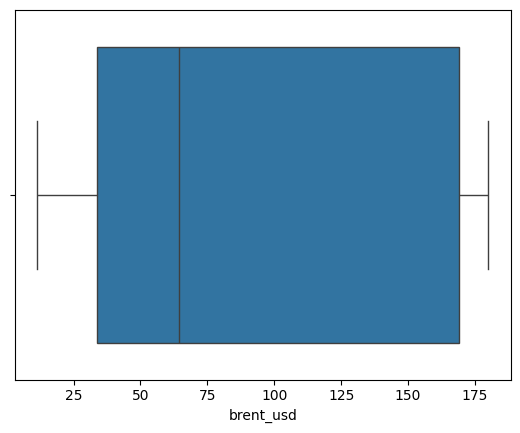

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['brent_usd'])
plt.show()

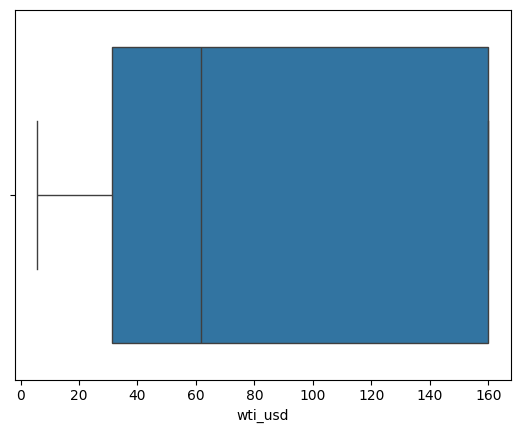

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['wti_usd'])
plt.show()

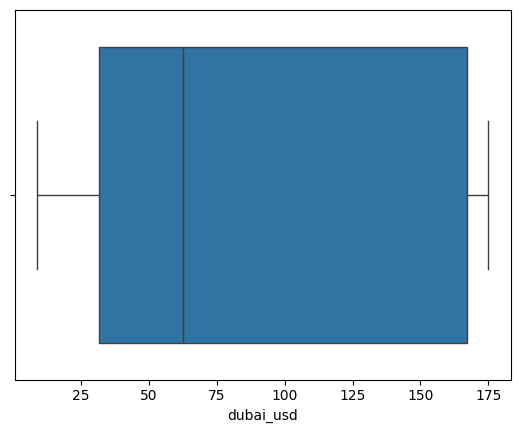

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['dubai_usd'])
plt.show()

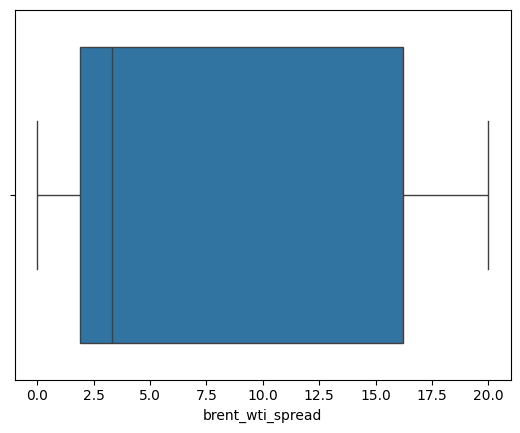

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['brent_wti_spread'])
plt.show()

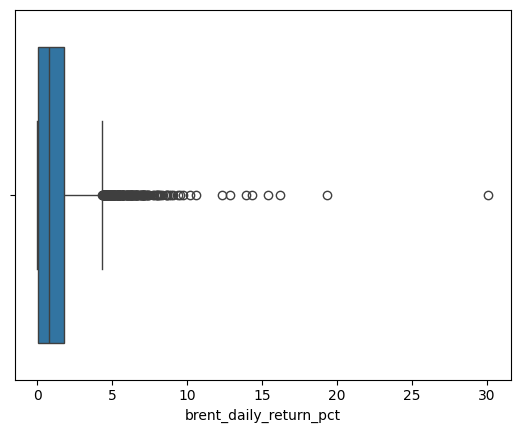

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['brent_daily_return_pct'])
plt.show()

In [58]:
Q1 = prices_df['brent_daily_return_pct'].quantile(0.25)
Q3 = prices_df['brent_daily_return_pct'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

prices_df['brent_daily_return_pct'] = prices_df['brent_daily_return_pct'].clip(upper=upper)

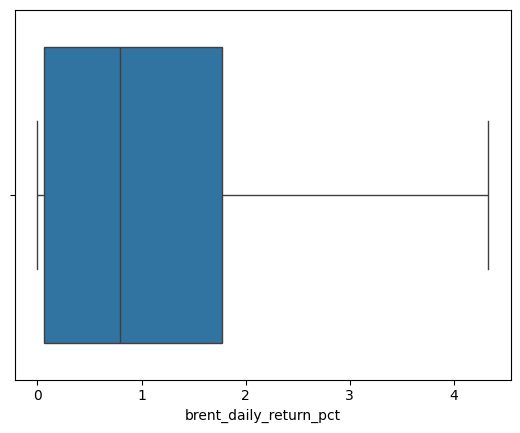

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['brent_daily_return_pct'])
plt.show()

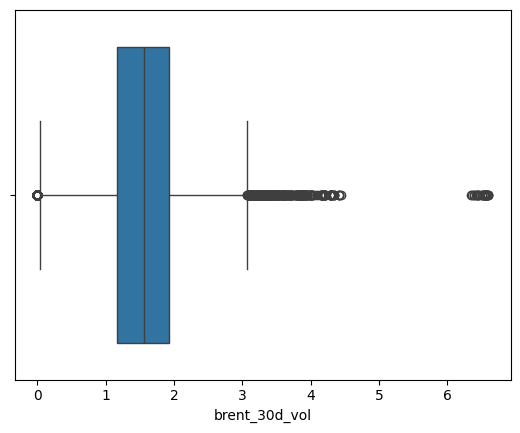

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['brent_30d_vol'])
plt.show()

In [61]:
Q1 = prices_df['brent_30d_vol'].quantile(0.25)
Q3 = prices_df['brent_30d_vol'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

prices_df['brent_30d_vol'] = prices_df['brent_30d_vol'].clip(upper=upper)

Q1 = prices_df['brent_30d_vol'].quantile(0.25)
Q3 = prices_df['brent_30d_vol'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

prices_df['brent_30d_vol'] = prices_df['brent_30d_vol'].clip(lower=lower)

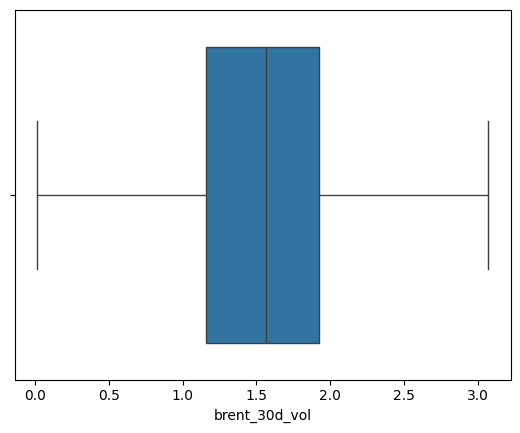

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['brent_30d_vol'])
plt.show()

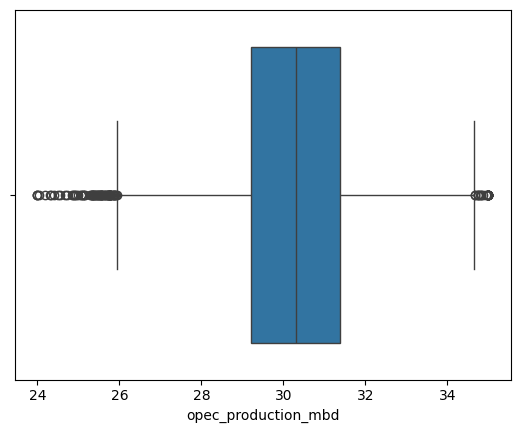

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['opec_production_mbd'])
plt.show()

In [64]:
Q1=prices_df['opec_production_mbd'].quantile(0.25)
Q3=prices_df['opec_production_mbd'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
prices_df['opec_production_mbd'] = prices_df['opec_production_mbd'].clip(lower=lower)

Q1=prices_df['opec_production_mbd'].quantile(0.25)
Q3=prices_df['opec_production_mbd'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
prices_df['opec_production_mbd'] = prices_df['opec_production_mbd'].clip(lower=lower, upper=upper)


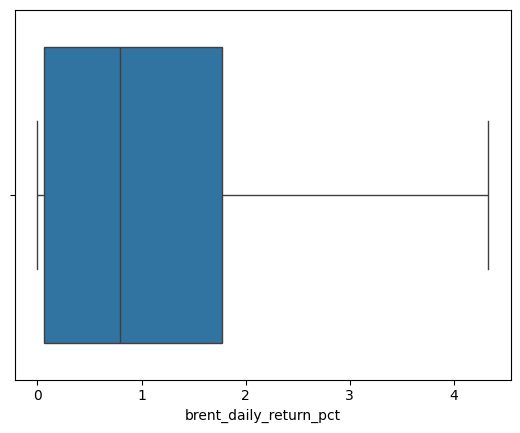

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['brent_daily_return_pct'])
plt.show()

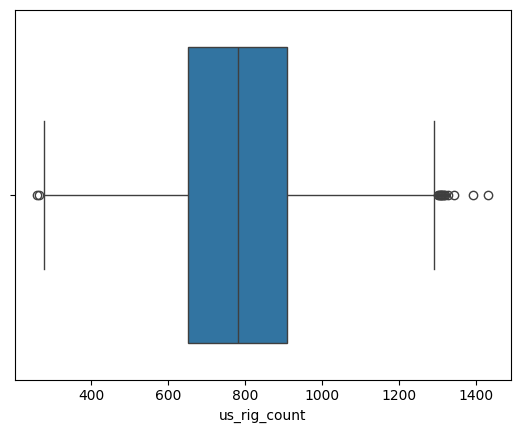

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['us_rig_count'])
plt.show()

In [67]:
Q1=prices_df['us_rig_count'].quantile(0.25)
Q3=prices_df['us_rig_count'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
prices_df['us_rig_count'] = prices_df['us_rig_count'].clip(lower=lower)

Q1=prices_df['us_rig_count'].quantile(0.25)
Q3=prices_df['us_rig_count'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
prices_df['us_rig_count'] = prices_df['us_rig_count'].clip(lower=lower, upper=upper)


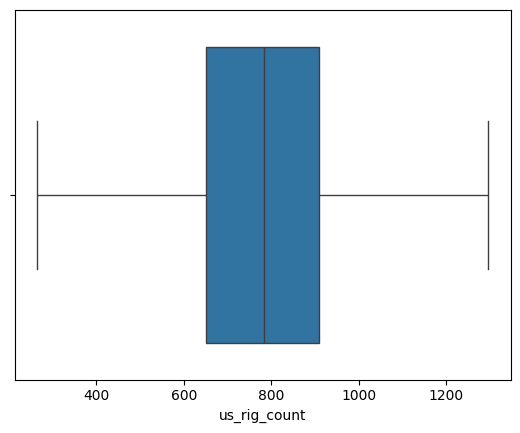

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['us_rig_count'])
plt.show()

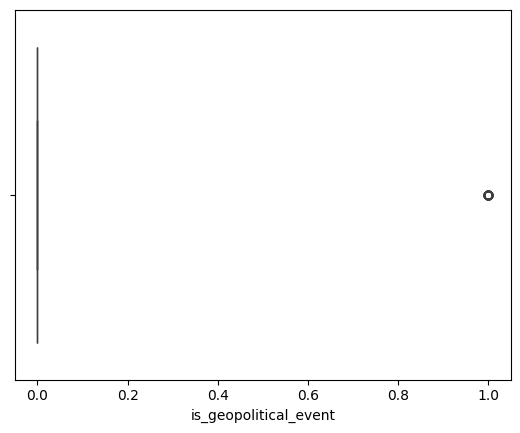

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['is_geopolitical_event'])
plt.show()

In [70]:
Q1=prices_df['is_geopolitical_event'].quantile(0.25)
Q3=prices_df['is_geopolitical_event'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
prices_df['is_geopolitical_event'] = prices_df['is_geopolitical_event'].clip(upper=upper)

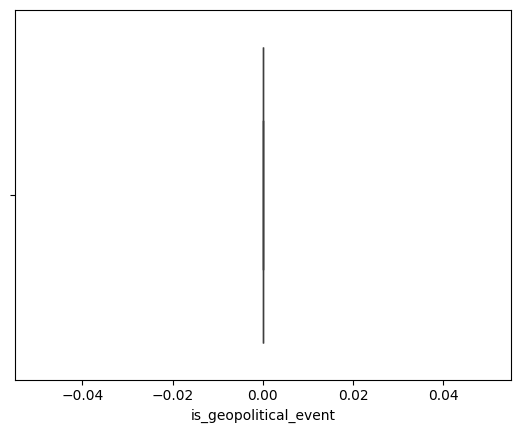

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['is_geopolitical_event'])
plt.show()

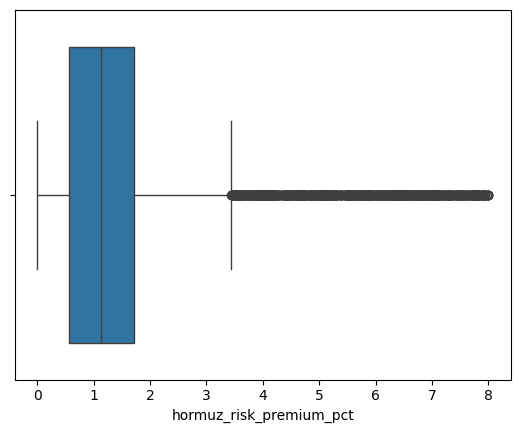

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['hormuz_risk_premium_pct'])
plt.show()

In [73]:
Q1=prices_df['hormuz_risk_premium_pct'].quantile(0.25)
Q3=prices_df['hormuz_risk_premium_pct'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
prices_df['hormuz_risk_premium_pct'] = prices_df['hormuz_risk_premium_pct'].clip(upper=upper)

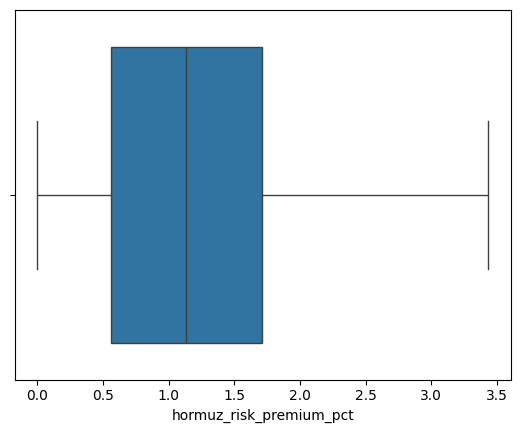

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=prices_df['hormuz_risk_premium_pct'])
plt.show()

# 5. EDA (Exploratory Data Analysis)

**How do Brent crude oil, WTI crude oil, and Dubai crude oil prices evolve over time?**

In [75]:
prices_df['date'] = pd.to_datetime(prices_df['date'])
prices_df['year'] = prices_df['date'].dt.year

In [76]:
yearly_prices = prices_df.groupby('year')[['brent_usd','wti_usd','dubai_usd']].mean().reset_index()

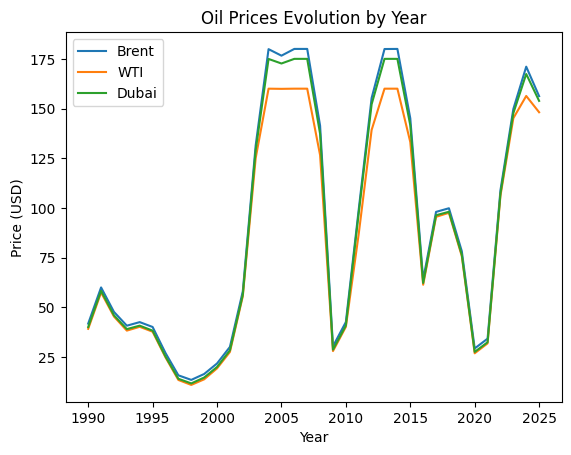

In [77]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(yearly_prices['year'], yearly_prices['brent_usd'])
plt.plot(yearly_prices['year'], yearly_prices['wti_usd'])
plt.plot(yearly_prices['year'], yearly_prices['dubai_usd'])

plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.title('Oil Prices Evolution by Year')

plt.legend(['Brent', 'WTI', 'Dubai'])

plt.show()

**Why did oil prices drop between ~1995 - 2000?**

In [78]:
df_period9520 = prices_df[(prices_df['year'] >= 1995) & (prices_df['year'] <= 2000)]

In [79]:
yearly = df_period9520.groupby('year')[['brent_usd','wti_usd','dubai_usd']].mean().reset_index()
yearly

,year,brent_usd,wti_usd,dubai_usd
0,1995,40.090385,37.706731,38.237115
1,1996,26.998893,24.802939,25.238015
2,1997,15.755594,13.426015,14.028352
3,1998,13.462835,10.929234,11.692069
4,1999,16.425747,13.740690,14.643333
5,2000,21.721923,19.248000,19.955808


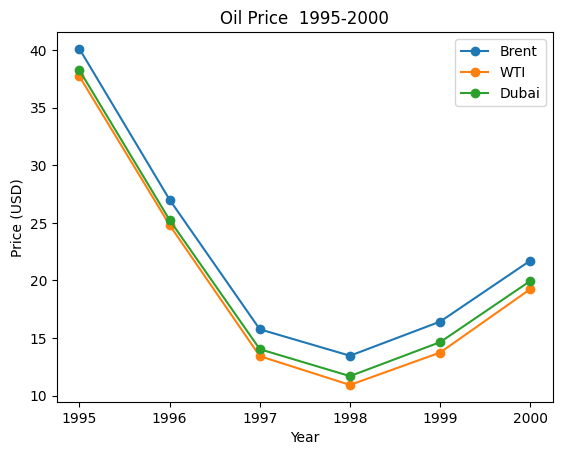

In [80]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(yearly['year'], yearly['brent_usd'], marker='o')
plt.plot(yearly['year'], yearly['wti_usd'], marker='o')
plt.plot(yearly['year'], yearly['dubai_usd'], marker='o')

plt.title("Oil Price  1995-2000")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend(['Brent', 'WTI', 'Dubai'])

plt.show()

**What geopolitical events occurred in 1998?**

In [81]:
events_df['date'] = pd.to_datetime(events_df['date'], errors='coerce')
events_1998 = events_df[events_df['date'].dt.year == 1998]
events_1998[['date', 'event_name', 'event_type', 'region', 'iran_involved', 'price_shock_pct', 'shock_direction', 'severity']]

,date,event_name,event_type,region,iran_involved,price_shock_pct,shock_direction,severity
3,1998-12-16,Operation Desert Fox (Iraq bombing),military,Middle East,0,8.0,up,medium


**Why did oil prices drop after 2008?**

In [82]:
df_period2008 = prices_df[(prices_df['year'] >= 2006) & (prices_df['year'] <= 2015)]

In [83]:
yearly1 = df_period2008.groupby('year')[['brent_usd','wti_usd','dubai_usd']].mean().reset_index()
yearly1

,year,brent_usd,wti_usd,dubai_usd
0,2006,180.000000,160.000000,175.000000
1,2007,180.000000,160.000000,175.000000
2,2008,141.356489,126.572214,137.278092
3,2009,30.353372,27.958927,28.675172
4,2010,42.582146,40.164866,40.851188
5,2011,99.277154,87.014808,97.494269
6,2012,155.285096,139.237510,152.150690
7,2013,179.948927,159.997510,175.000000
8,2014,180.000000,160.000000,175.000000
9,2015,145.114828,133.163755,141.610153


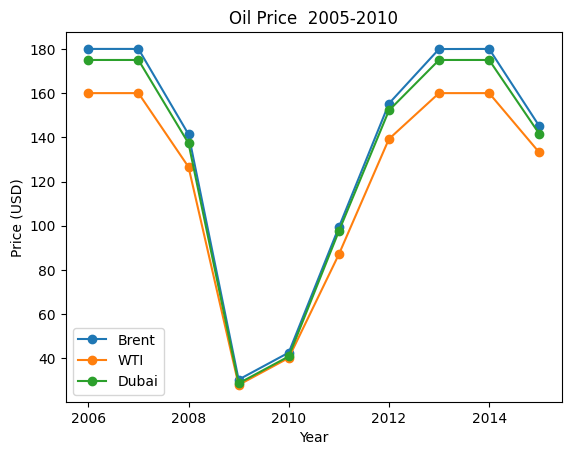

In [84]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(yearly1['year'], yearly1['brent_usd'], marker='o')
plt.plot(yearly1['year'], yearly1['wti_usd'], marker='o')
plt.plot(yearly1['year'], yearly1['dubai_usd'], marker='o')

plt.title("Oil Price  2005-2010")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend(['Brent', 'WTI', 'Dubai'])

plt.show()

**What geopolitical events occurred in 2008 to 2010?**

In [85]:
events_df['date'] = pd.to_datetime(events_df['date'], errors='coerce')
events_2008_2010 = events_df[(events_df['date'].dt.year >= 2008) & (events_df['date'].dt.year <= 2010)]
events_2008_2010[['date', 'event_name', 'event_type', 'region', 'iran_involved', 'price_shock_pct', 'shock_direction', 'severity']]

,date,event_name,event_type,region,iran_involved,price_shock_pct,shock_direction,severity
12,2008-07-11,Brent hits $147 (record high),market,Global,0,0.0,neutral,extreme
13,2008-09-15,Lehman Brothers collapse,economic,Global,0,-35.0,down,extreme
14,2009-06-12,Iran election protests (Green Movement),political,Middle East,1,3.0,up,low
15,2010-06-09,UN Security Council adopts Resolution 1929,sanctions,Global,0,4.0,up,medium


In [86]:
df_period1825 = prices_df[(prices_df['year'] >= 2019) & (prices_df['year'] <= 2025)]

In [87]:
yearly2= df_period1825.groupby('year')[['brent_usd','wti_usd','dubai_usd']].mean().reset_index()
yearly2

,year,brent_usd,wti_usd,dubai_usd
0,2019,78.199540,75.692069,76.409923
1,2020,29.285992,26.844046,27.540420
2,2021,34.203831,31.843333,32.403678
3,2022,108.890308,106.166077,107.163923
4,2023,149.741462,145.139615,147.662038
5,2024,171.065115,156.328435,167.383397
6,2025,156.220482,148.134217,153.847711


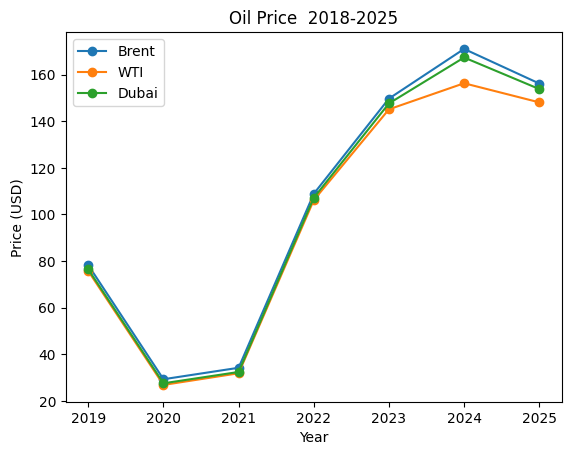

In [88]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(yearly2['year'], yearly2['brent_usd'], marker='o')
plt.plot(yearly2['year'], yearly2['wti_usd'], marker='o')
plt.plot(yearly2['year'], yearly2['dubai_usd'], marker='o')

plt.title("Oil Price  2018-2025")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend(['Brent', 'WTI', 'Dubai'])

plt.show()

**What geopolitical events occurred in 2018 to 2025?**

In [89]:
events_df['date'] = pd.to_datetime(events_df['date'], errors='coerce')
events_2018_2025 = events_df[(events_df['date'].dt.year >= 2018) & (events_df['date'].dt.year <= 2025)]
events_2018_2025[['date', 'event_name', 'event_type', 'region', 'iran_involved', 'price_shock_pct', 'shock_direction', 'severity']]

,date,event_name,event_type,region,iran_involved,price_shock_pct,shock_direction,severity
31,2018-05-08,Trump withdraws from JCPOA,sanctions,Global,1,5.0,up,high
32,2018-11-05,US Iran sanctions reimposed,sanctions,Middle East,1,-3.0,down,medium
33,2019-05-02,US ends Iran sanction waivers,sanctions,Middle East,1,3.0,up,medium
34,2019-05-12,Saudi tanker attacks near Fujairah,military,Middle East,0,3.0,up,medium
35,2019-06-13,Tanker attacks in Gulf of Oman,military,Middle East,0,4.0,up,medium
36,2019-09-14,Houthi/Iran attack on Abqaiq-Khurais,military,Middle East,1,15.0,up,extreme
37,2019-09-17,Saudi Arabia restores output,market,Middle East,0,-8.0,down,high
38,2020-01-03,Qasem Soleimani killed by US drone,military,Global,1,4.0,up,high
39,2020-01-08,Iran strikes US bases in Iraq,military,Middle East,1,3.0,up,medium
40,2020-03-08,Saudi Arabia launches oil price war,market,Middle East,0,-25.0,down,extreme


**Events on 2020 and 2004?**

In [90]:
events_df['date'] = pd.to_datetime(events_df['date'], errors='coerce')
event_2020=events_df[(events_df['date'].dt.year == 2020)]
event_2020[['date', 'event_name', 'event_type', 'region', 'iran_involved', 'price_shock_pct', 'shock_direction', 'severity']]

,date,event_name,event_type,region,iran_involved,price_shock_pct,shock_direction,severity
38,2020-01-03,Qasem Soleimani killed by US drone,military,Global,1,4.0,up,high
39,2020-01-08,Iran strikes US bases in Iraq,military,Middle East,1,3.0,up,medium
40,2020-03-08,Saudi Arabia launches oil price war,market,Middle East,0,-25.0,down,extreme
41,2020-04-12,OPEC+ agrees record 9.7M bpd cut,market,Global,0,12.0,up,high
42,2020-04-20,WTI goes negative for first time,market,Global,0,-100.0,down,extreme


In [91]:
event_2024=events_df[(events_df['date'].dt.year == 2024)]
event_2024[['date', 'event_name', 'event_type', 'region', 'iran_involved', 'price_shock_pct', 'shock_direction', 'severity']]

,date,event_name,event_type,region,iran_involved,price_shock_pct,shock_direction,severity
57,2024-01-11,US/UK strike Houthi targets in Yemen,military,Middle East,0,3.0,up,medium
58,2024-02-12,Houthis escalate Red Sea attacks,military,Middle East,0,4.0,up,medium
59,2024-04-01,Israel strikes Iran consulate Damascus,military,Middle East,1,4.0,up,high
60,2024-04-13,Iran direct missile/drone attack on Israel,military,Middle East,1,3.0,up,high
61,2024-04-19,Israel retaliates against Iran,military,Middle East,1,2.0,up,medium
62,2024-06-12,Saudi Arabia renews voluntary cuts,market,Middle East,0,2.0,up,medium
63,2024-10-01,Iran fires ballistic missiles at Israel,military,Middle East,1,5.0,up,high
64,2024-10-26,Israel strikes Iran military sites,military,Middle East,1,3.0,up,high


**How many geopolitical events involve Iran compared to those that do not?**

In [92]:
events_df['iran_involved'].value_counts()

iran_involved
0    43
1    25
Name: count, dtype: int64

**What is the global events?**

In [93]:
global_events = events_df[events_df['iran_involved'] == 0]
global_events[['date', 'event_name', 'event_type', 'region', 'price_shock_pct', 'shock_direction', 'severity']]

,date,event_name,event_type,region,price_shock_pct,shock_direction,severity
0,1990-08-02,Iraq invades Kuwait,military,Middle East,28.0,up,extreme
1,1991-01-17,Gulf War begins (Operation Desert Storm),military,Middle East,-15.0,down,high
2,1991-02-28,Gulf War ceasefire,diplomatic,Middle East,-12.0,down,high
3,1998-12-16,Operation Desert Fox (Iraq bombing),military,Middle East,8.0,up,medium
4,2001-09-11,9/11 attacks,terror,Global,12.0,up,extreme
5,2002-10-16,US Congress authorizes Iraq war,political,Middle East,10.0,up,high
6,2003-03-20,US invasion of Iraq begins,military,Middle East,18.0,up,extreme
7,2003-05-01,Bush declares end of major combat,political,Global,-14.0,down,high
10,2006-07-12,Israel-Lebanon war begins,military,Middle East,6.0,up,medium
12,2008-07-11,Brent hits $147 (record high),market,Global,0.0,neutral,extreme


**What types of geopolitical events involving Iran occurred, and what price shocks did they generate**

In [94]:
iran_events = events_df[events_df['iran_involved'] == 1]
iran_events[['date', 'event_name', 'event_type', 'region', 'price_shock_pct', 'severity']]

,date,event_name,event_type,region,price_shock_pct,severity
8,2005-06-24,Ahmadinejad elected Iran president,political,Middle East,5.0,medium
9,2006-01-10,Iran resumes uranium enrichment,sanctions,Middle East,7.0,high
11,2007-10-25,US imposes new Iran sanctions,sanctions,Middle East,4.0,medium
14,2009-06-12,Iran election protests (Green Movement),political,Middle East,3.0,low
19,2012-01-23,EU oil embargo on Iran,sanctions,Middle East,5.0,high
20,2012-07-01,EU Iran oil embargo takes effect,sanctions,Middle East,3.0,medium
24,2015-07-14,Iran nuclear deal (JCPOA) signed,diplomatic,Middle East,-8.0,high
26,2016-01-16,Iran sanctions lifted (JCPOA),sanctions,Middle East,-5.0,high
31,2018-05-08,Trump withdraws from JCPOA,sanctions,Global,5.0,high
32,2018-11-05,US Iran sanctions reimposed,sanctions,Middle East,-3.0,medium


**what the years that we  have  highest price for brent oil?**

In [95]:
highest_brent_year = yearly_prices.loc[yearly_prices['brent_usd'].idxmax()]
print(highest_brent_year)

year         2006.0
brent_usd     180.0
wti_usd       160.0
dubai_usd     175.0
Name: 16, dtype: float64


**what the top 5 years with highest average Brent prices?**

In [96]:
top_brent_years = yearly_prices.sort_values(by='brent_usd', ascending=False).head(5)
top_brent_years

,year,brent_usd,wti_usd,dubai_usd
17,2007,180.000000,160.00000,175.000000
24,2014,180.000000,160.00000,175.000000
16,2006,180.000000,160.00000,175.000000
23,2013,179.948927,159.99751,175.000000
14,2004,179.884427,160.00000,174.949809


**what the top 5 years with highest average WTI prices?**

In [97]:
top_wti_years = yearly_prices.sort_values(by='wti_usd', ascending=False).head(5)
top_wti_years

,year,brent_usd,wti_usd,dubai_usd
24,2014,180.000000,160.00000,175.000000
14,2004,179.884427,160.00000,174.949809
17,2007,180.000000,160.00000,175.000000
16,2006,180.000000,160.00000,175.000000
23,2013,179.948927,159.99751,175.000000


**what top 5 years with highest average Dubai prices?**

In [98]:
top_dubai_years = yearly_prices.sort_values(by='dubai_usd', ascending=False).head(5)
top_dubai_years

,year,brent_usd,wti_usd,dubai_usd
23,2013,179.948927,159.99751,175.000000
24,2014,180.000000,160.00000,175.000000
17,2007,180.000000,160.00000,175.000000
16,2006,180.000000,160.00000,175.000000
14,2004,179.884427,160.00000,174.949809


**which events caused the highest oil price shocks?**


In [99]:
events_by_shock = events_df.nlargest(10, 'price_shock_pct')[['date', 'event_name', 'event_type', 'price_shock_pct', 'shock_direction', 'severity']]
events_by_shock


,date,event_name,event_type,price_shock_pct,shock_direction,severity
0,1990-08-02,Iraq invades Kuwait,military,28.0,up,extreme
46,2022-02-24,Russia invades Ukraine,military,22.0,up,extreme
6,2003-03-20,US invasion of Iraq begins,military,18.0,up,extreme
17,2011-02-17,Libya civil war begins,military,15.0,up,high
36,2019-09-14,Houthi/Iran attack on Abqaiq-Khurais,military,15.0,up,extreme
4,2001-09-11,9/11 attacks,terror,12.0,up,extreme
41,2020-04-12,OPEC+ agrees record 9.7M bpd cut,market,12.0,up,high
5,2002-10-16,US Congress authorizes Iraq war,political,10.0,up,high
3,1998-12-16,Operation Desert Fox (Iraq bombing),military,8.0,up,medium
16,2011-01-25,Arab Spring begins (Egypt),political,8.0,up,high


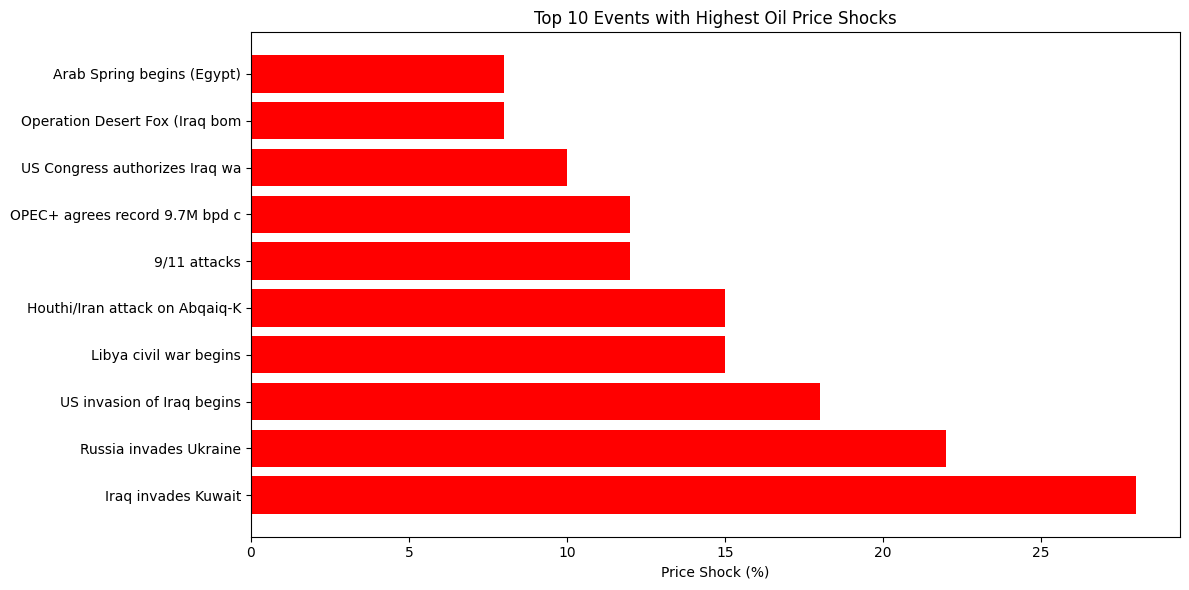

In [100]:
# Visualize top 10 events by price shock
plt.figure(figsize=(12, 6))
top_events = events_df.nlargest(10, 'price_shock_pct')
plt.barh(range(len(top_events)), top_events['price_shock_pct'], color=['red' if x == 'up' else 'green' for x in top_events['shock_direction']])
plt.yticks(range(len(top_events)), [e[:30] for e in top_events['event_name']])
plt.xlabel('Price Shock (%)')
plt.title('Top 10 Events with Highest Oil Price Shocks')
plt.tight_layout()
plt.show()

**which events caused the losses oil price shocks?**


In [101]:
events_df[events_df['price_shock_pct'] < 0][['date', 'event_name', 'event_type', 'price_shock_pct', 'shock_direction', 'severity']]

,date,event_name,event_type,price_shock_pct,shock_direction,severity
1,1991-01-17,Gulf War begins (Operation Desert Storm),military,-15.0,down,high
2,1991-02-28,Gulf War ceasefire,diplomatic,-12.0,down,high
7,2003-05-01,Bush declares end of major combat,political,-14.0,down,high
13,2008-09-15,Lehman Brothers collapse,economic,-35.0,down,extreme
18,2011-10-20,"Gaddafi killed, Libya war ends",political,-8.0,down,medium
21,2013-09-09,US-Russia Syria deal (chemical weapons),diplomatic,-5.0,down,medium
23,2014-11-27,OPEC refuses to cut production,market,-10.0,down,high
24,2015-07-14,Iran nuclear deal (JCPOA) signed,diplomatic,-8.0,down,high
25,2015-12-04,OPEC maintains output (price war),market,-12.0,down,high
26,2016-01-16,Iran sanctions lifted (JCPOA),sanctions,-5.0,down,high


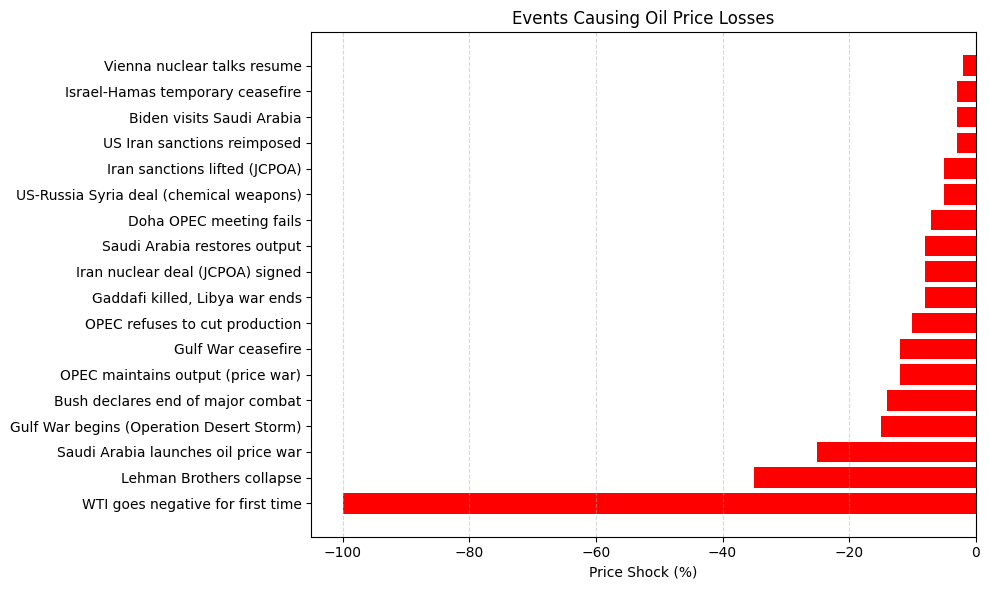

In [102]:
neg_shocks = events_df[events_df['price_shock_pct'] < 0].sort_values('price_shock_pct')

plt.figure(figsize=(10, 6))
plt.barh(neg_shocks['event_name'], neg_shocks['price_shock_pct'], color='red')
plt.xlabel('Price Shock (%)')
plt.title('Events Causing Oil Price Losses')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Iran exports over time with sanctions periods highlighted**

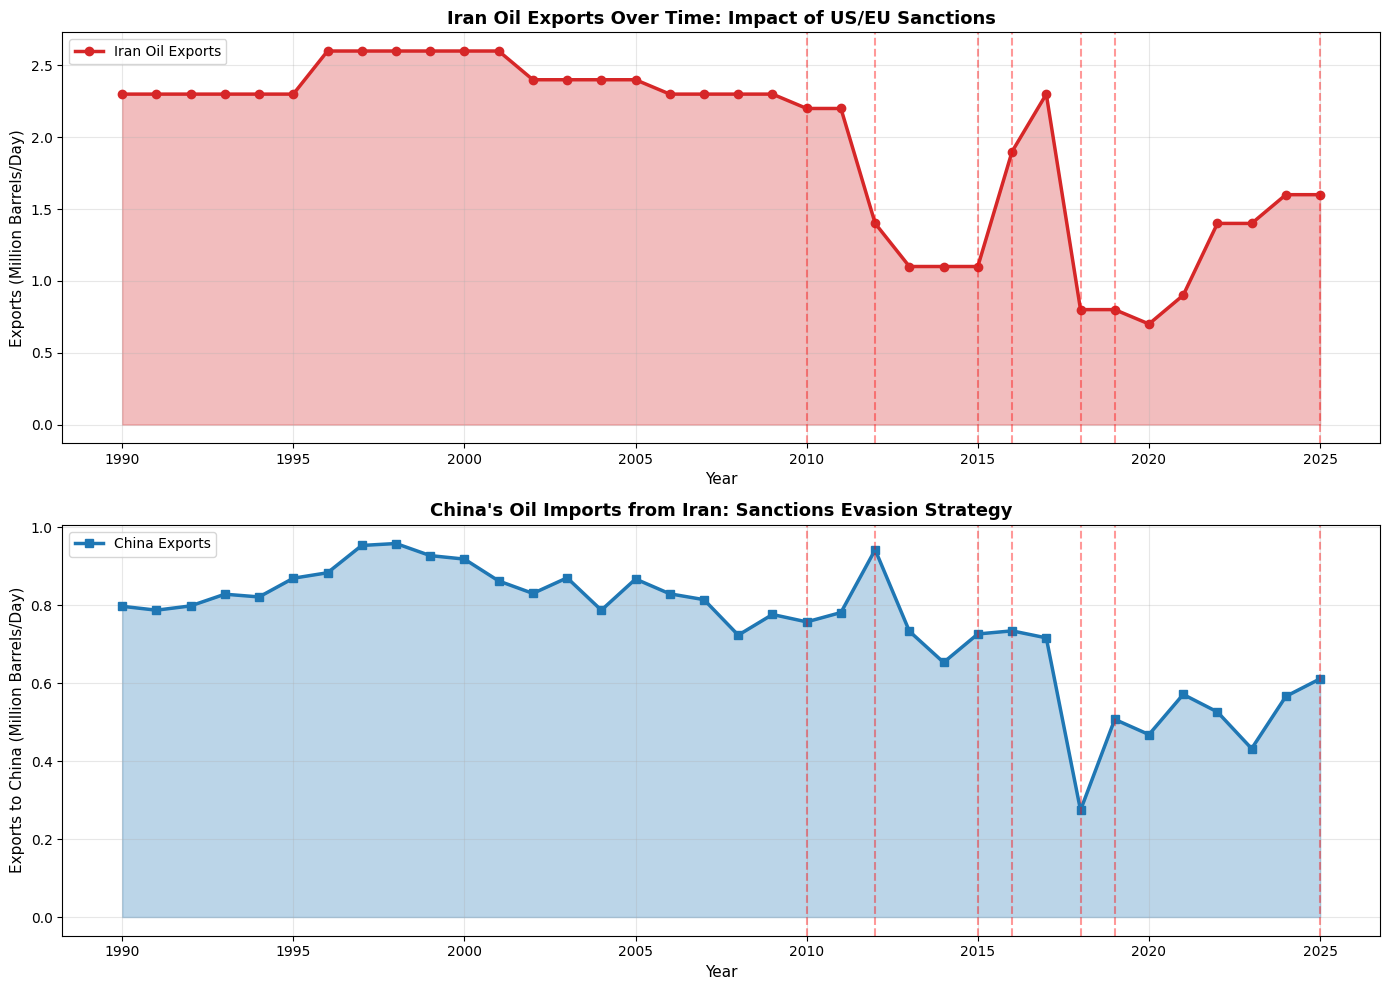

Iran Oil Export Impact Analysis

Average exports before heavy sanctions (2010): 2.41 mbd
Average exports during peak sanctions (2018-2020): 0.77 mbd
Average exports after JCPOA (2016-2017): 2.10 mbd

China's dominance: 37.2% of total Iran exports


In [103]:
# Merge prices and sanctions data to analyze impact
sanctions_df['date'] = pd.to_datetime(sanctions_df['date'])
prices_sanctions = prices_df.merge(sanctions_df, on='date', how='left')

# Prepare Iran exports data
iran_yearly = exports_df[['year', 'total_iran_exports_mbd']].drop_duplicates().sort_values('year')
china_exports = exports_df[exports_df['destination'] == 'China'].sort_values('year')
top_dest = exports_df.groupby('destination')['exports_mbd'].sum()

# Create a visualization showing Iran exports over time with sanctions periods highlighted
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Iran's total oil exports over time
ax1.plot(iran_yearly['year'], iran_yearly['total_iran_exports_mbd'], 
         marker='o', linewidth=2.5, markersize=6, color='#d62728', label='Iran Oil Exports')
ax1.fill_between(iran_yearly['year'], iran_yearly['total_iran_exports_mbd'], alpha=0.3, color='#d62728')

# Highlight major sanctions periods
sanctions_years_int = [2010, 2012, 2015, 2016, 2018, 2019, 2025]
for year in sanctions_years_int:
    ax1.axvline(x=year, color='red', linestyle='--', alpha=0.4, linewidth=1.5)

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Exports (Million Barrels/Day)', fontsize=11)
ax1.set_title('Iran Oil Exports Over Time: Impact of US/EU Sanctions', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: China's share of Iran exports
china_exports = exports_df[exports_df['destination'] == 'China'].sort_values('year')
ax2.plot(china_exports['year'], china_exports['exports_mbd'], 
         marker='s', linewidth=2.5, markersize=6, color='#1f77b4', label='China Exports')
ax2.fill_between(china_exports['year'], china_exports['exports_mbd'], alpha=0.3, color='#1f77b4')

# Highlight sanctions periods
for year in sanctions_years_int:
    ax2.axvline(x=year, color='red', linestyle='--', alpha=0.4, linewidth=1.5)

ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Exports to China (Million Barrels/Day)', fontsize=11)
ax2.set_title("China's Oil Imports from Iran: Sanctions Evasion Strategy", fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("Iran Oil Export Impact Analysis")
print("=" * 50)
print(f"\nAverage exports before heavy sanctions (2010): {iran_yearly[iran_yearly['year'] < 2010]['total_iran_exports_mbd'].mean():.2f} mbd")
print(f"Average exports during peak sanctions (2018-2020): {iran_yearly[(iran_yearly['year'] >= 2018) & (iran_yearly['year'] <= 2020)]['total_iran_exports_mbd'].mean():.2f} mbd")
print(f"Average exports after JCPOA (2016-2017): {iran_yearly[(iran_yearly['year'] >= 2016) & (iran_yearly['year'] <= 2017)]['total_iran_exports_mbd'].mean():.2f} mbd")
print(f"\nChina's dominance: {top_dest['China']/top_dest.sum()*100:.1f}% of total Iran exports")

**Average Oil Imports from Iran by Top Destinations (2018-2025)**

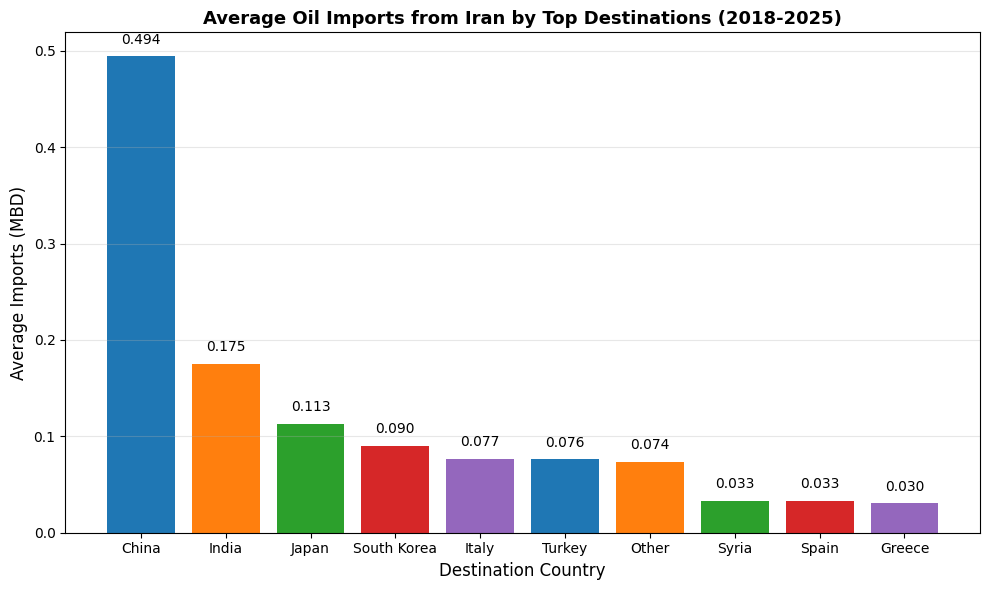

In [104]:
import matplotlib.pyplot as plt

# Filter exports_df for 2018-2025
exports_2018_2025 = exports_df[(exports_df['year'] >= 2018) & (exports_df['year'] <= 2025)]

# Calculate average imports by destination for 2018-2025
avg_imports_by_dest = exports_2018_2025.groupby('destination')['exports_mbd'].mean().sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(avg_imports_by_dest.index, avg_imports_by_dest.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.xlabel('Destination Country', fontsize=12)
plt.ylabel('Average Imports (MBD)', fontsize=12)
plt.title('Average Oil Imports from Iran by Top Destinations (2018-2025)', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(avg_imports_by_dest.values):
	plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**The relationship between Geopolitical Risk Index and Hormuz risk premium**


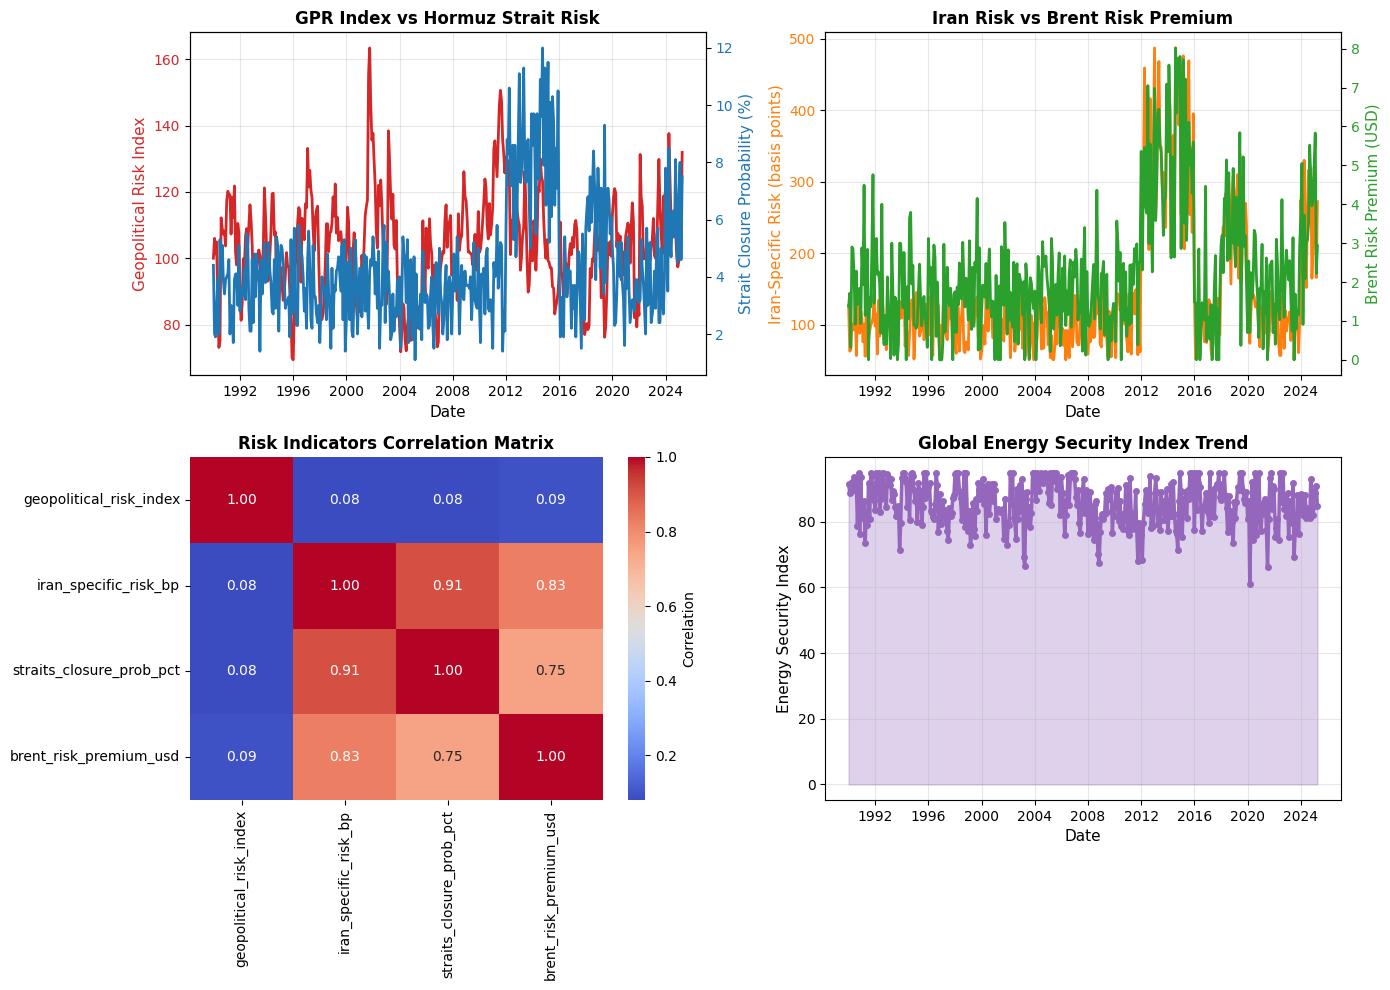

Geopolitical Risk Analysis Summary

Geopolitical Risk Index (GPR):
  Mean: 103.95
  Median: 103.30
  Max: 163.40 (in 2001-10-01 00:00:00)
  Min: 69.40

Iran-Specific Risk (basis points):
  Mean: 141.7 bp
  Max: 487.0 bp (in 2013-01-01 00:00:00)

Strait of Hormuz Closure Probability:
  Mean: 4.37%
  Max: 12.00% (in 2014-10-01 00:00:00)

Brent Risk Premium:
  Mean: $2.24
  Max: $8.02

Correlation (GPR Index vs Brent Risk Premium): 0.092


In [105]:
# Analyze the relationship between Geopolitical Risk Index and Hormuz risk premium
risk_df['date'] = pd.to_datetime(risk_df['date'])

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: GPR Index and Hormuz Risk Premium over time
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(risk_df['date'], risk_df['geopolitical_risk_index'], color='#d62728', linewidth=2, label='GPR Index')
ax1_twin.plot(risk_df['date'], risk_df['straits_closure_prob_pct'], color='#1f77b4', linewidth=2, label='Strait Closure Probability')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Geopolitical Risk Index', fontsize=11, color='#d62728')
ax1_twin.set_ylabel('Strait Closure Probability (%)', fontsize=11, color='#1f77b4')
ax1.set_title('GPR Index vs Hormuz Strait Risk', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='#d62728')
ax1_twin.tick_params(axis='y', labelcolor='#1f77b4')

# Plot 2: Iran-specific risk and Brent risk premium
ax2 = axes[0, 1]
ax2_twin = ax2.twinx()
ax2.plot(risk_df['date'], risk_df['iran_specific_risk_bp'], color='#ff7f0e', linewidth=2, label='Iran Risk (bp)')
ax2_twin.plot(risk_df['date'], risk_df['brent_risk_premium_usd'], color='#2ca02c', linewidth=2, label='Brent Risk Premium')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Iran-Specific Risk (basis points)', fontsize=11, color='#ff7f0e')
ax2_twin.set_ylabel('Brent Risk Premium (USD)', fontsize=11, color='#2ca02c')
ax2.set_title('Iran Risk vs Brent Risk Premium', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax2_twin.tick_params(axis='y', labelcolor='#2ca02c')

# Plot 3: Correlation heatmap
ax3 = axes[1, 0]
risk_subset = risk_df[['geopolitical_risk_index', 'iran_specific_risk_bp', 'straits_closure_prob_pct', 'brent_risk_premium_usd']].corr()
sns.heatmap(risk_subset, annot=True, fmt='.2f', cmap='coolwarm', ax=ax3, cbar_kws={'label': 'Correlation'})
ax3.set_title('Risk Indicators Correlation Matrix', fontsize=12, fontweight='bold')

# Plot 4: Energy security index trend
ax4 = axes[1, 1]
ax4.plot(risk_df['date'], risk_df['energy_security_index'], color='#9467bd', linewidth=2.5, marker='o', markersize=4)
ax4.fill_between(risk_df['date'], risk_df['energy_security_index'], alpha=0.3, color='#9467bd')
ax4.set_xlabel('Date', fontsize=11)
ax4.set_ylabel('Energy Security Index', fontsize=11)
ax4.set_title('Global Energy Security Index Trend', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("Geopolitical Risk Analysis Summary")
print("=" * 60)
print(f"\nGeopolitical Risk Index (GPR):")
print(f"  Mean: {risk_df['geopolitical_risk_index'].mean():.2f}")
print(f"  Median: {risk_df['geopolitical_risk_index'].median():.2f}")
print(f"  Max: {risk_df['geopolitical_risk_index'].max():.2f} (in {risk_df.loc[risk_df['geopolitical_risk_index'].idxmax(), 'date']})")
print(f"  Min: {risk_df['geopolitical_risk_index'].min():.2f}")

print(f"\nIran-Specific Risk (basis points):")
print(f"  Mean: {risk_df['iran_specific_risk_bp'].mean():.1f} bp")
print(f"  Max: {risk_df['iran_specific_risk_bp'].max():.1f} bp (in {risk_df.loc[risk_df['iran_specific_risk_bp'].idxmax(), 'date']})")

print(f"\nStrait of Hormuz Closure Probability:")
print(f"  Mean: {risk_df['straits_closure_prob_pct'].mean():.2f}%")
print(f"  Max: {risk_df['straits_closure_prob_pct'].max():.2f}% (in {risk_df.loc[risk_df['straits_closure_prob_pct'].idxmax(), 'date']})")

print(f"\nBrent Risk Premium:")
print(f"  Mean: ${risk_df['brent_risk_premium_usd'].mean():.2f}")
print(f"  Max: ${risk_df['brent_risk_premium_usd'].max():.2f}")

correlation = risk_df['geopolitical_risk_index'].corr(risk_df['brent_risk_premium_usd'])
print(f"\nCorrelation (GPR Index vs Brent Risk Premium): {correlation:.3f}")

**How has Morocco’s total expenditure on oil imports evolved over time?**

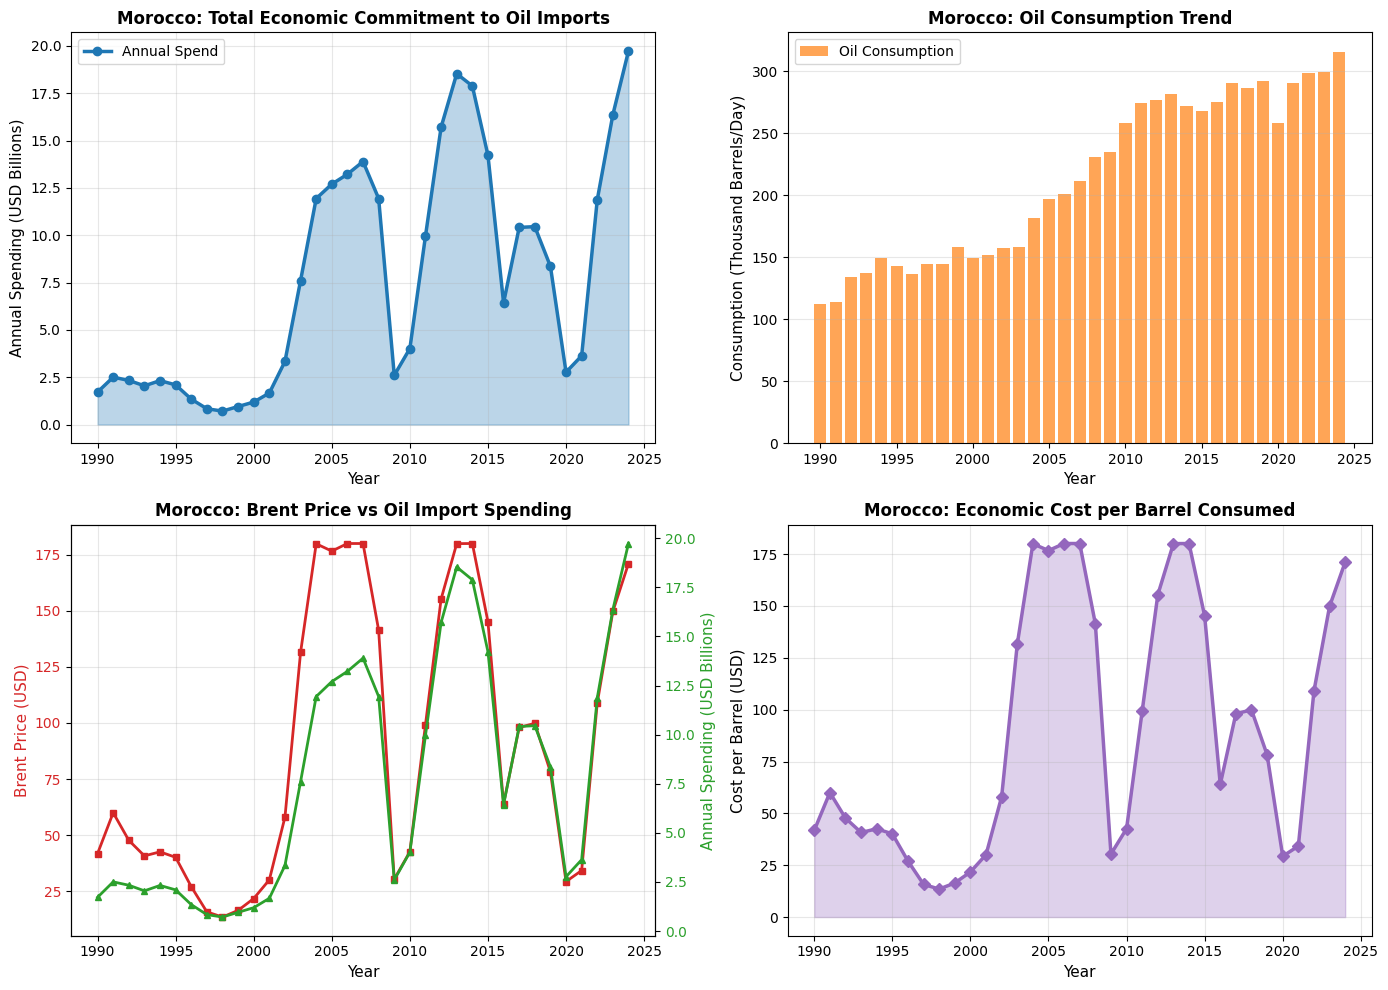

Morocco's Total Economic Commitment to Oil Imports - Analysis

Total Spending Summary:
  Total cumulative spend (1990-2024): $267.31 billion
  Average annual spending: $7.64 billion
  Median annual spending: $6.43 billion
  Peak spending year: 2024 ($19.73 billion)
  Lowest spending year: 1998 ($0.71 billion)

Oil Consumption Summary:
  Average consumption: 214.00 thousand barrels/day
  Growth from 1990 to 2024: 180.5%

Brent Price Impact:
  Average Brent price: $88.86
  Price range: $13.46 - $180.00

Economic Burden:
  Highest economic burden year: 2014


In [106]:
import matplotlib.pyplot as plt

# Analyze Morocco's total economic commitment to oil imports over time
morr_yearly = morr_df.copy()

# Create visualizations for Morocco's oil spending
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Annual spending over time
ax1 = axes[0, 0]
ax1.plot(morr_yearly['year'], morr_yearly['annual_spend_bn_usd'], 
         marker='o', linewidth=2.5, markersize=6, color='#1f77b4', label='Annual Spend')
ax1.fill_between(morr_yearly['year'], morr_yearly['annual_spend_bn_usd'], alpha=0.3, color='#1f77b4')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Annual Spending (USD Billions)', fontsize=11)
ax1.set_title('Morocco: Total Economic Commitment to Oil Imports', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Oil consumption trend
ax2 = axes[0, 1]
ax2.bar(morr_yearly['year'], morr_yearly['consumption_kbpd'], color='#ff7f0e', alpha=0.7, label='Oil Consumption')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Consumption (Thousand Barrels/Day)', fontsize=11)
ax2.set_title('Morocco: Oil Consumption Trend', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=10)

# Plot 3: Brent price impact
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
ax3.plot(morr_yearly['year'], morr_yearly['brent_usd'], 
         marker='s', linewidth=2, markersize=5, color='#d62728', label='Brent Price')
ax3_twin.plot(morr_yearly['year'], morr_yearly['annual_spend_bn_usd'], 
         marker='^', linewidth=2, markersize=5, color='#2ca02c', label='Annual Spend')
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Brent Price (USD)', fontsize=11, color='#d62728')
ax3_twin.set_ylabel('Annual Spending (USD Billions)', fontsize=11, color='#2ca02c')
ax3.set_title('Morocco: Brent Price vs Oil Import Spending', fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='#d62728')
ax3_twin.tick_params(axis='y', labelcolor='#2ca02c')
ax3.grid(True, alpha=0.3)

# Plot 4: Economic burden analysis
ax4 = axes[1, 1]
spending_per_barrel = morr_yearly['annual_spend_bn_usd'] * 1e9 / (morr_yearly['consumption_kbpd'] * 365 * 1000)
ax4.plot(morr_yearly['year'], spending_per_barrel, 
         marker='D', linewidth=2.5, markersize=6, color='#9467bd')
ax4.fill_between(morr_yearly['year'], spending_per_barrel, alpha=0.3, color='#9467bd')
ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Cost per Barrel (USD)', fontsize=11)
ax4.set_title('Morocco: Economic Cost per Barrel Consumed', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("Morocco's Total Economic Commitment to Oil Imports - Analysis")
print("=" * 70)
print(f"\nTotal Spending Summary:")
print(f"  Total cumulative spend (1990-2024): ${morr_yearly['annual_spend_bn_usd'].sum():.2f} billion")
print(f"  Average annual spending: ${morr_yearly['annual_spend_bn_usd'].mean():.2f} billion")
print(f"  Median annual spending: ${morr_yearly['annual_spend_bn_usd'].median():.2f} billion")
print(f"  Peak spending year: {morr_yearly.loc[morr_yearly['annual_spend_bn_usd'].idxmax(), 'year']:.0f} (${morr_yearly['annual_spend_bn_usd'].max():.2f} billion)")
print(f"  Lowest spending year: {morr_yearly.loc[morr_yearly['annual_spend_bn_usd'].idxmin(), 'year']:.0f} (${morr_yearly['annual_spend_bn_usd'].min():.2f} billion)")

print(f"\nOil Consumption Summary:")
print(f"  Average consumption: {morr_yearly['consumption_kbpd'].mean():.2f} thousand barrels/day")
print(f"  Growth from 1990 to 2024: {((morr_yearly.iloc[-1]['consumption_kbpd'] - morr_yearly.iloc[0]['consumption_kbpd']) / morr_yearly.iloc[0]['consumption_kbpd'] * 100):.1f}%")

print(f"\nBrent Price Impact:")
print(f"  Average Brent price: ${morr_yearly['brent_usd'].mean():.2f}")
print(f"  Price range: ${morr_yearly['brent_usd'].min():.2f} - ${morr_yearly['brent_usd'].max():.2f}")

print(f"\nEconomic Burden:")
highest_burden_idx = (morr_yearly['annual_spend_bn_usd'] / morr_yearly['consumption_kbpd']).idxmax()
print(f"  Highest economic burden year: {morr_yearly.loc[highest_burden_idx, 'year']:.0f}")

Between 1990 and 2024, Morocco’s cumulative investment in crude oil imports reached an estimated $267.31 Billion USD. This figure underscores the massive capital outflow required to sustain a developing economy in a volatile geopolitical climate.

**How has Morocco’s total energy demand grown over the past decades?**

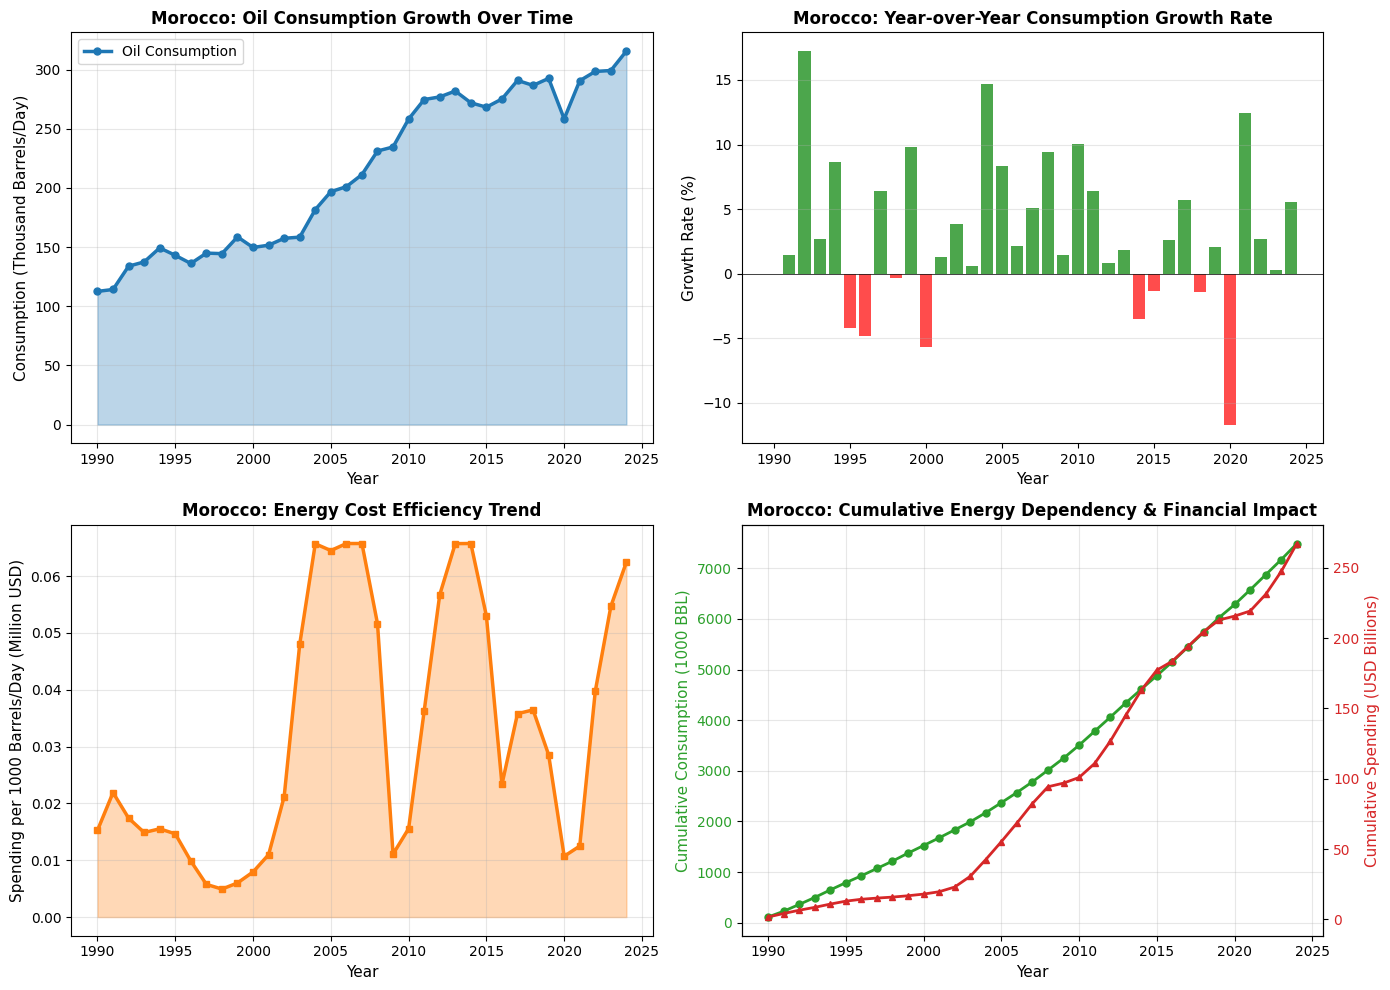

Morocco's Energy Dependency & Demand Growth Analysis

Consumption Growth (1990-2024):
  1990 Consumption: 112.57 thousand barrels/day
  2024 Consumption: 315.81 thousand barrels/day
  Total Growth: 180.5%
  Average Annual Growth Rate: 5.31%
  Highest growth year: 1992 (17.24%)

Energy Dependency Metrics:
  Total cumulative consumption (1990-2024): 7490 thousand barrels
  Average annual consumption: 214.00 thousand barrels/day
  Consumption volatility (std dev): 66.72

Financial Impact:
  Total cumulative spending (1990-2024): $267.31 billion
  Average annual spending: $7.64 billion
  Peak spending year: 2024 ($19.73 billion)

Cost Efficiency:
  Average spending per 1000 barrels/day: $0.03 million
  Most expensive year: 2014 ($0.07 million)
  Least expensive year: 1998 ($0.00 million)


In [107]:
# Analyze Morocco's energy dependency and demand growth trends

# Calculate energy dependency metrics
morr_yearly['annual_consumption_mbd'] = morr_yearly['consumption_kbpd'] / 1000
morr_yearly['consumption_growth_pct'] = morr_yearly['consumption_kbpd'].pct_change() * 100
morr_yearly['spending_growth_pct'] = morr_yearly['annual_spend_bn_usd'].pct_change() * 100
morr_yearly['price_efficiency'] = morr_yearly['annual_spend_bn_usd'] / morr_yearly['consumption_kbpd']

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Consumption growth trajectory
ax1 = axes[0, 0]
ax1.plot(morr_yearly['year'], morr_yearly['consumption_kbpd'], 
		 marker='o', linewidth=2.5, markersize=5, color='#1f77b4', label='Oil Consumption')
ax1.fill_between(morr_yearly['year'], morr_yearly['consumption_kbpd'], alpha=0.3, color='#1f77b4')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Consumption (Thousand Barrels/Day)', fontsize=11)
ax1.set_title('Morocco: Oil Consumption Growth Over Time', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Year-over-year consumption growth rate
ax2 = axes[0, 1]
colors = ['green' if x > 0 else 'red' for x in morr_yearly['consumption_growth_pct'].fillna(0)]
ax2.bar(morr_yearly['year'], morr_yearly['consumption_growth_pct'].fillna(0), color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Growth Rate (%)', fontsize=11)
ax2.set_title('Morocco: Year-over-Year Consumption Growth Rate', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Spending efficiency (spending per unit consumption)
ax3 = axes[1, 0]
ax3.plot(morr_yearly['year'], morr_yearly['price_efficiency'], 
		 marker='s', linewidth=2.5, markersize=5, color='#ff7f0e')
ax3.fill_between(morr_yearly['year'], morr_yearly['price_efficiency'], alpha=0.3, color='#ff7f0e')
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Spending per 1000 Barrels/Day (Million USD)', fontsize=11)
ax3.set_title('Morocco: Energy Cost Efficiency Trend', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Cumulative consumption and spending comparison
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
cumulative_consumption = morr_yearly['consumption_kbpd'].cumsum()
cumulative_spending = morr_yearly['annual_spend_bn_usd'].cumsum()
ax4.plot(morr_yearly['year'], cumulative_consumption, 
		 marker='o', linewidth=2, markersize=5, color='#2ca02c', label='Cumulative Consumption')
ax4_twin.plot(morr_yearly['year'], cumulative_spending, 
		 marker='^', linewidth=2, markersize=5, color='#d62728', label='Cumulative Spending')
ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Cumulative Consumption (1000 BBL)', fontsize=11, color='#2ca02c')
ax4_twin.set_ylabel('Cumulative Spending (USD Billions)', fontsize=11, color='#d62728')
ax4.set_title('Morocco: Cumulative Energy Dependency & Financial Impact', fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='#2ca02c')
ax4_twin.tick_params(axis='y', labelcolor='#d62728')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics for energy dependency
print("Morocco's Energy Dependency & Demand Growth Analysis")
print("=" * 70)

consumption_start = morr_yearly.iloc[0]['consumption_kbpd']
consumption_end = morr_yearly.iloc[-1]['consumption_kbpd']
consumption_growth_total = ((consumption_end - consumption_start) / consumption_start) * 100

print(f"\nConsumption Growth (1990-2024):")
print(f"  1990 Consumption: {consumption_start:.2f} thousand barrels/day")
print(f"  2024 Consumption: {consumption_end:.2f} thousand barrels/day")
print(f"  Total Growth: {consumption_growth_total:.1f}%")
print(f"  Average Annual Growth Rate: {consumption_growth_total / 34:.2f}%")
print(f"  Highest growth year: {morr_yearly.loc[morr_yearly['consumption_growth_pct'].idxmax(), 'year']:.0f} ({morr_yearly['consumption_growth_pct'].max():.2f}%)")

print(f"\nEnergy Dependency Metrics:")
print(f"  Total cumulative consumption (1990-2024): {cumulative_consumption.iloc[-1]:.0f} thousand barrels")
print(f"  Average annual consumption: {morr_yearly['consumption_kbpd'].mean():.2f} thousand barrels/day")
print(f"  Consumption volatility (std dev): {morr_yearly['consumption_kbpd'].std():.2f}")

print(f"\nFinancial Impact:")
print(f"  Total cumulative spending (1990-2024): ${cumulative_spending.iloc[-1]:.2f} billion")
print(f"  Average annual spending: ${morr_yearly['annual_spend_bn_usd'].mean():.2f} billion")
print(f"  Peak spending year: {morr_yearly.loc[morr_yearly['annual_spend_bn_usd'].idxmax(), 'year']:.0f} (${morr_yearly['annual_spend_bn_usd'].max():.2f} billion)")

print(f"\nCost Efficiency:")
print(f"  Average spending per 1000 barrels/day: ${morr_yearly['price_efficiency'].mean():.2f} million")
print(f"  Most expensive year: {morr_yearly.loc[morr_yearly['price_efficiency'].idxmax(), 'year']:.0f} (${morr_yearly['price_efficiency'].max():.2f} million)")
print(f"  Least expensive year: {morr_yearly.loc[morr_yearly['price_efficiency'].idxmin(), 'year']:.0f} (${morr_yearly['price_efficiency'].min():.2f} million)")

**How does geopolitical instability increase the effective cost of oil imports for Morocco?**

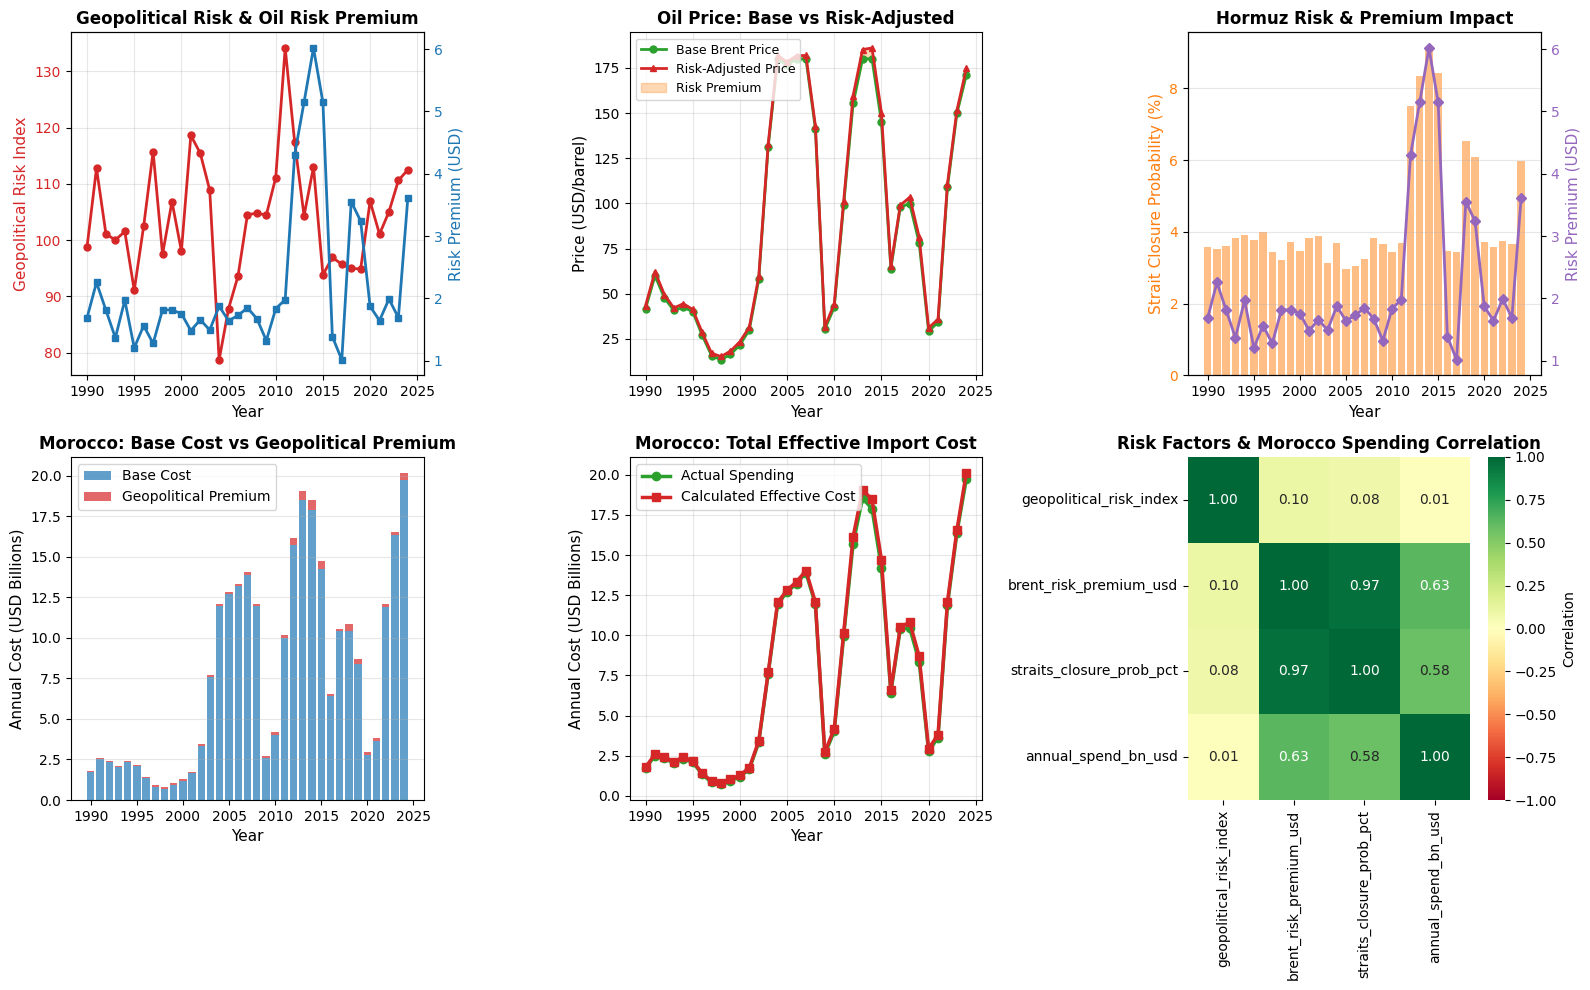

Geopolitical Instability Impact on Morocco's Oil Import Costs

Total Cumulative Impact (1990-2024):
  Base import cost: $267.12 billion
  Geopolitical premium: $6.53 billion
  Total effective cost: $273.65 billion
  Geopolitical premium as % of spending: 2.4%

Worst Years (High Geopolitical Risk):
  2014: GPR=113.0, Premium=$6.02/bbl, Cost=$0.598B
  2013: GPR=104.3, Premium=$5.15/bbl, Cost=$0.530B
  2015: GPR=93.8, Premium=$5.14/bbl, Cost=$0.504B
  2012: GPR=117.5, Premium=$4.30/bbl, Cost=$0.435B
  2024: GPR=112.5, Premium=$3.61/bbl, Cost=$0.416B

Risk Correlation with Morocco Spending:
  GPR Index correlation: 0.009
  Brent Risk Premium correlation: 0.632
  Strait Closure Probability correlation: 0.578

Average Annual Geopolitical Premium:
  Per barrel: $2.22
  Annual cost increase (avg): $0.173 billion


In [108]:
import seaborn as sns

# Analyze how geopolitical instability increases Morocco's effective oil import costs

# Merge relevant datasets
morr_yearly['date'] = pd.to_datetime(morr_yearly['year'].astype(str) + '-01-01')
risk_yearly = risk_df.groupby('year')[['geopolitical_risk_index', 'iran_specific_risk_bp', 
                                         'straits_closure_prob_pct', 'brent_risk_premium_usd', 
                                         'energy_security_index']].mean().reset_index()

morr_risk = morr_yearly.merge(risk_yearly, on='year', how='inner')

# Calculate additional cost metrics
morr_risk['risk_adjusted_price'] = morr_risk['brent_usd'] + morr_risk['brent_risk_premium_usd']
morr_risk['base_import_cost'] = morr_risk['consumption_kbpd'] * 365 * morr_risk['brent_usd'] / 1e6
morr_risk['geopolitical_cost_premium'] = morr_risk['consumption_kbpd'] * 365 * morr_risk['brent_risk_premium_usd'] / 1e6
morr_risk['total_effective_cost'] = morr_risk['base_import_cost'] + morr_risk['geopolitical_cost_premium']

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: GPR Index vs Brent Risk Premium
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(morr_risk['year'], morr_risk['geopolitical_risk_index'], 
         marker='o', linewidth=2, markersize=5, color='#d62728', label='GPR Index')
ax1_twin.plot(morr_risk['year'], morr_risk['brent_risk_premium_usd'], 
         marker='s', linewidth=2, markersize=5, color='#1f77b4', label='Brent Risk Premium')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Geopolitical Risk Index', fontsize=11, color='#d62728')
ax1_twin.set_ylabel('Risk Premium (USD)', fontsize=11, color='#1f77b4')
ax1.set_title('Geopolitical Risk & Oil Risk Premium', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#d62728')
ax1_twin.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3)

# Plot 2: Base price vs Risk-adjusted price
ax2 = axes[0, 1]
ax2.plot(morr_risk['year'], morr_risk['brent_usd'], 
         marker='o', linewidth=2, markersize=5, color='#2ca02c', label='Base Brent Price')
ax2.plot(morr_risk['year'], morr_risk['risk_adjusted_price'], 
         marker='^', linewidth=2, markersize=5, color='#d62728', label='Risk-Adjusted Price')
ax2.fill_between(morr_risk['year'], morr_risk['brent_usd'], morr_risk['risk_adjusted_price'], 
                 alpha=0.3, color='#ff7f0e', label='Risk Premium')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('Price (USD/barrel)', fontsize=11)
ax2.set_title('Oil Price: Base vs Risk-Adjusted', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.3)

# Plot 3: Strait closure probability impact
ax3 = axes[0, 2]
ax3_twin = ax3.twinx()
ax3.bar(morr_risk['year'], morr_risk['straits_closure_prob_pct'], 
        alpha=0.5, color='#ff7f0e', label='Strait Closure Risk')
ax3_twin.plot(morr_risk['year'], morr_risk['brent_risk_premium_usd'], 
         marker='D', linewidth=2, markersize=5, color='#9467bd', label='Risk Premium')
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Strait Closure Probability (%)', fontsize=11, color='#ff7f0e')
ax3_twin.set_ylabel('Risk Premium (USD)', fontsize=11, color='#9467bd')
ax3.set_title('Hormuz Risk & Premium Impact', fontsize=12, fontweight='bold')
ax3.tick_params(axis='y', labelcolor='#ff7f0e')
ax3_twin.tick_params(axis='y', labelcolor='#9467bd')
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Base vs Geopolitical cost for Morocco
ax4 = axes[1, 0]
ax4.bar(morr_risk['year'], morr_risk['base_import_cost'], 
        label='Base Cost', alpha=0.7, color='#1f77b4')
ax4.bar(morr_risk['year'], morr_risk['geopolitical_cost_premium'], 
        bottom=morr_risk['base_import_cost'], label='Geopolitical Premium', 
        alpha=0.7, color='#d62728')
ax4.set_xlabel('Year', fontsize=11)
ax4.set_ylabel('Annual Cost (USD Billions)', fontsize=11)
ax4.set_title('Morocco: Base Cost vs Geopolitical Premium', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# Plot 5: Total effective cost breakdown
ax5 = axes[1, 1]
ax5.plot(morr_risk['year'], morr_risk['annual_spend_bn_usd'], 
         marker='o', linewidth=2.5, markersize=6, color='#2ca02c', label='Actual Spending')
ax5.plot(morr_risk['year'], morr_risk['total_effective_cost'], 
         marker='s', linewidth=2.5, markersize=6, color='#d62728', label='Calculated Effective Cost')
ax5.fill_between(morr_risk['year'], morr_risk['annual_spend_bn_usd'], 
                 morr_risk['total_effective_cost'], alpha=0.2, color='#ff7f0e')
ax5.set_xlabel('Year', fontsize=11)
ax5.set_ylabel('Annual Cost (USD Billions)', fontsize=11)
ax5.set_title('Morocco: Total Effective Import Cost', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# Plot 6: Correlation analysis
ax6 = axes[1, 2]
correlation_data = morr_risk[['geopolitical_risk_index', 'brent_risk_premium_usd', 
                               'straits_closure_prob_pct', 'annual_spend_bn_usd']].corr()
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax6, 
            cbar_kws={'label': 'Correlation'}, center=0, vmin=-1, vmax=1)
ax6.set_title('Risk Factors & Morocco Spending Correlation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary analysis
print("Geopolitical Instability Impact on Morocco's Oil Import Costs")
print("=" * 75)

total_geopolitical_premium = morr_risk['geopolitical_cost_premium'].sum()
total_actual_spending = morr_risk['annual_spend_bn_usd'].sum()
premium_percentage = (total_geopolitical_premium / total_actual_spending) * 100

print(f"\nTotal Cumulative Impact (1990-2024):")
print(f"  Base import cost: ${morr_risk['base_import_cost'].sum():.2f} billion")
print(f"  Geopolitical premium: ${total_geopolitical_premium:.2f} billion")
print(f"  Total effective cost: ${morr_risk['total_effective_cost'].sum():.2f} billion")
print(f"  Geopolitical premium as % of spending: {premium_percentage:.1f}%")

print(f"\nWorst Years (High Geopolitical Risk):")
worst_years = morr_risk.nlargest(5, 'geopolitical_cost_premium')[['year', 'geopolitical_risk_index', 
                                                                    'brent_risk_premium_usd', 
                                                                    'geopolitical_cost_premium']]
for idx, row in worst_years.iterrows():
    print(f"  {int(row['year'])}: GPR={row['geopolitical_risk_index']:.1f}, " +
          f"Premium=${row['brent_risk_premium_usd']:.2f}/bbl, Cost=${row['geopolitical_cost_premium']:.3f}B")

print(f"\nRisk Correlation with Morocco Spending:")
corr_gpr = morr_risk['geopolitical_risk_index'].corr(morr_risk['annual_spend_bn_usd'])
corr_premium = morr_risk['brent_risk_premium_usd'].corr(morr_risk['annual_spend_bn_usd'])
corr_strait = morr_risk['straits_closure_prob_pct'].corr(morr_risk['annual_spend_bn_usd'])
print(f"  GPR Index correlation: {corr_gpr:.3f}")
print(f"  Brent Risk Premium correlation: {corr_premium:.3f}")
print(f"  Strait Closure Probability correlation: {corr_strait:.3f}")

avg_premium = morr_risk['brent_risk_premium_usd'].mean()
print(f"\nAverage Annual Geopolitical Premium:")
print(f"  Per barrel: ${avg_premium:.2f}")
print(f"  Annual cost increase (avg): ${(morr_risk['consumption_kbpd'].mean() * 365 * avg_premium / 1e6):.3f} billion")


# 6. Final Statement

The oil market operates at the intersection of economics and geopolitics. Understanding its dynamics requires not only quantitative analysis but also contextual awareness of global events, strategic risks, and market psychology.

For a country like Morocco, these global shifts are not merely data points; they are drivers of national economic stability. Understanding the specific risk premium of regional chokepoints and the shifting alliances in the East (e.g., Iran-China) is essential for Morocco to navigate future energy security and maintain fiscal resilience against a backdrop of permanent global instability.